# If necessary install the below packages (libraries) before loading them
Use install.packages in terminal rather than in the notebook.

`mamba activate r432
R
install.packages()`

In [2]:
# Downstream analysis using object created by Sara Grimm
# Match the R version and important package versions used in the original analysis
# R432

library(Seurat);       # v5.0.1  
library(ggplot2);      # v3.4.4
library(dplyr);
library(viridis);
library(dittoSeq);
library(scales);
library(scCustomize)
library(tidyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite

Warning message:
“package ‘viridisLite’ was built under R version 4.3.3”
Warning message:
“package ‘scales’ was built under R version 4.3.3”

Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


scCustomize v3.0.1
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.

Warning message:
“package ‘tidyr’ was built under R version 4.3.3”


In [3]:
# Record active package versions
packageVersion("Seurat");
packageVersion("ggplot2");        
packageVersion("dplyr");
packageVersion("viridis");
packageVersion("dittoSeq");
packageVersion("scales");
packageVersion("scCustomize");
packageVersion("tidyr");

[1] ‘5.0.1’

[1] ‘3.4.4’

[1] ‘1.1.4’

[1] ‘0.6.5’

[1] ‘1.14.3’

[1] ‘1.3.0’

[1] ‘3.0.1’

[1] ‘1.3.1’

In [110]:
# Read in the processed RDS file from Sara Grimm, which holds a seurat object with filtered, integrated, annotated cells from 4 samples.
# We are using the broad clusters for these cell types
Adult_Srfflox_SrfKO <- readRDS("/ddn/gs1/home/marquardtrm/PRcreSRF_scRNAseq_Sara/data_rds/RM-adult_SrfKO-FilteredIntegratedAnnotated.14mar2025.rds")
Adult_Srfflox_SrfKO
head(Adult_Srfflox_SrfKO)

An object of class Seurat 
26486 features across 33500 samples within 1 assay 
Active assay: RNA (26486 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.rpca, umap

,orig.ident,nCount_RNA,nFeature_RNA,Sample,genotype,batch,percent.mt,percent.rp,percent.hg,S.Score,G2M.Score,Phase,old.ident,CC.Difference,broad_cluster,CellType,CellSubtype,CellTypeBroad
,<chr>,<dbl>,<int>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>
Ctrl1___AAACCCAAGACCATAA-1,Ctrl1,13853,4097,Ctrl1,Ctrl,1,4.858153,21.86530,0,-0.115882733,-0.10197415,G1,Ctrl1,-0.01390858,0,FibroblastF2,FibroblastF2,Fibroblast
Ctrl1___AAACCCAAGGTCCCGT-1,Ctrl1,5652,2163,Ctrl1,Ctrl,1,2.813163,11.34112,0,-0.087413046,-0.16113772,G1,Ctrl1,0.07372467,5,Macrophage,Macrophage,Immune
Ctrl1___AAACCCACATCACCAA-1,Ctrl1,6085,2336,Ctrl1,Ctrl,1,2.678718,10.56697,0,-0.070066492,-0.04961594,G1,Ctrl1,-0.02045055,15,gammadeltaT,gammadeltaT,Immune
Ctrl1___AAACCCACATCTAACG-1,Ctrl1,12378,3609,Ctrl1,Ctrl,1,3.869769,14.76006,0,-0.035871272,-0.09095433,G1,Ctrl1,0.05508306,11,SmoothMuscle,none,SmoothMuscle
Ctrl1___AAACCCACATGTCAGT-1,Ctrl1,15094,4189,Ctrl1,Ctrl,1,3.186697,23.22777,0,0.795792256,0.30071105,S,Ctrl1,0.49508121,10,ProliferatingNK,ProliferatingNK,Immune
Ctrl1___AAACCCAGTAATGTGA-1,Ctrl1,14440,4595,Ctrl1,Ctrl,1,4.903047,18.98199,0,0.056406385,0.58059310,G2M,Ctrl1,-0.52418671,7,ProliferatingFibroblastG2M,ProliferatingFibroblastG2M,Fibroblast
Ctrl1___AAACCCAGTGTAGGAC-1,Ctrl1,19929,4617,Ctrl1,Ctrl,1,5.996287,24.48191,0,-0.084860322,-0.12601747,G1,Ctrl1,0.04115715,3,GlandularEpithelial,GlandularEpithelial,Epithelial
Ctrl1___AAACCCATCGCCGAGT-1,Ctrl1,20720,5042,Ctrl1,Ctrl,1,4.917954,23.61004,0,-0.007086613,-0.04976484,G1,Ctrl1,0.04267823,0,FibroblastF2,FibroblastF2,Fibroblast
Ctrl1___AAACCCATCGGCAGTC-1,Ctrl1,15461,4527,Ctrl1,Ctrl,1,4.359356,15.99508,0,0.559701893,0.82661813,G2M,Ctrl1,-0.26691623,2,Endothelial,none,Endothelial


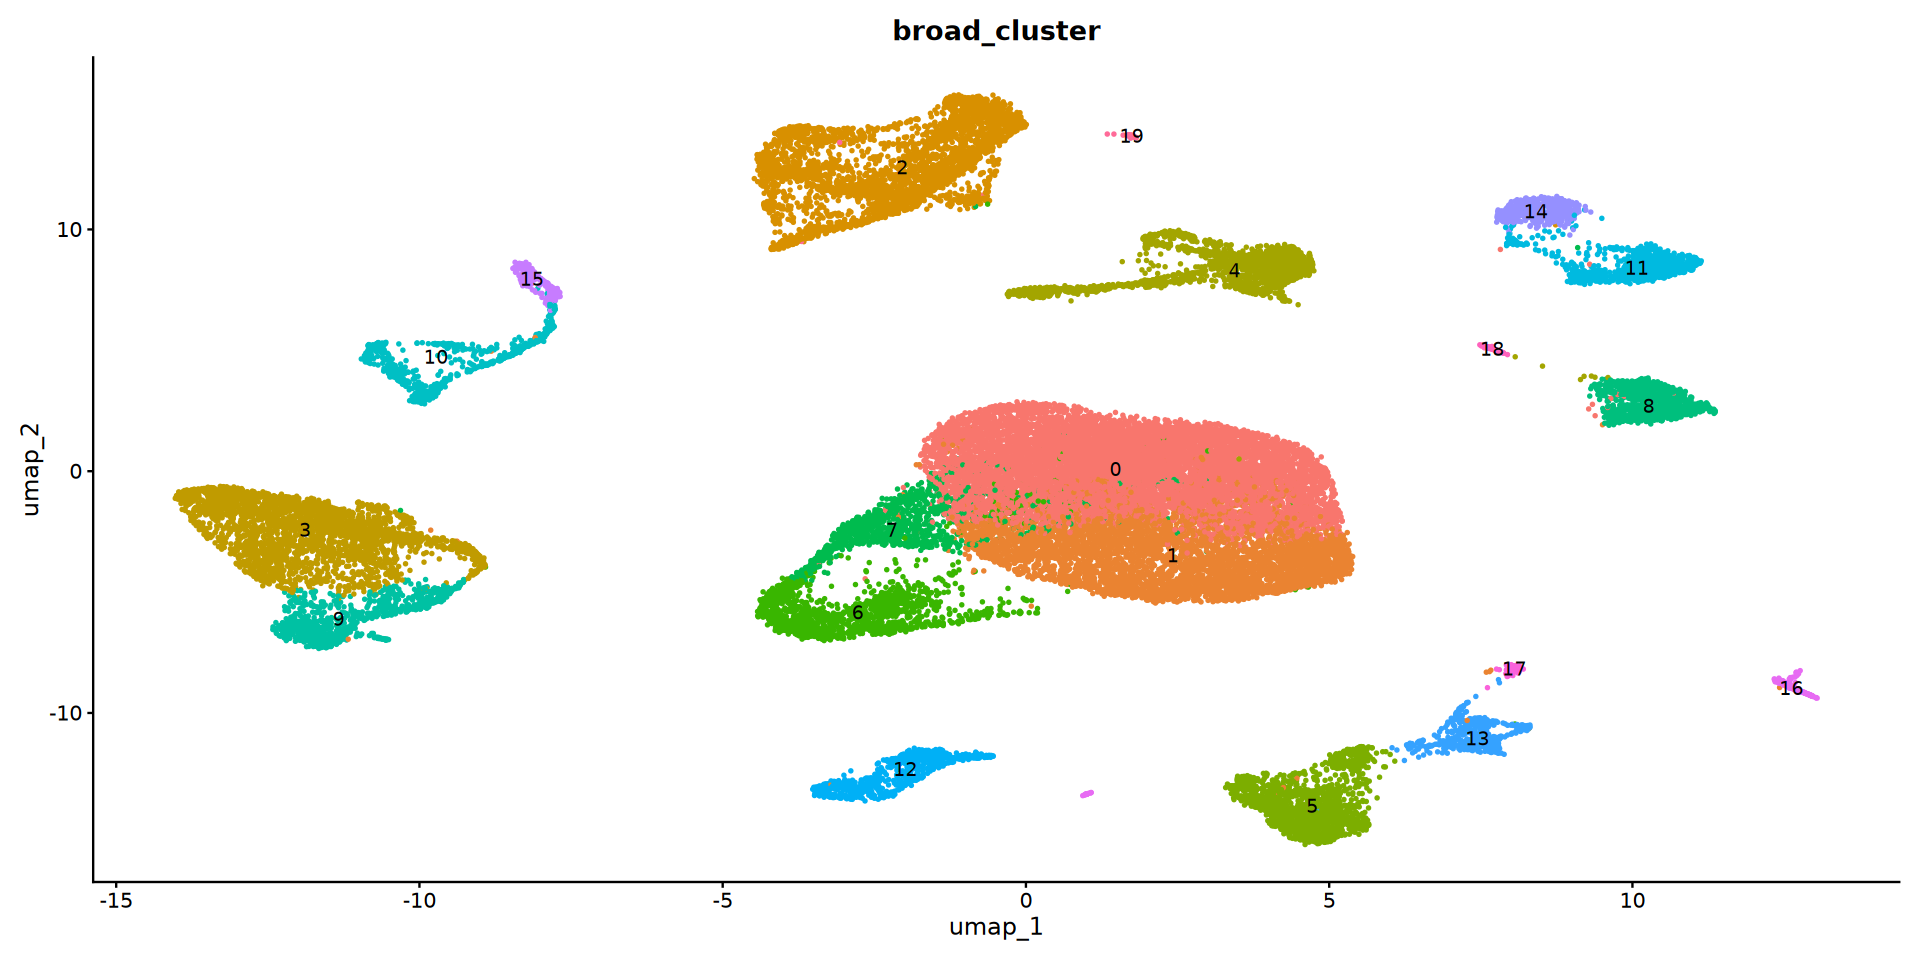

In [111]:
DimPlot(Adult_Srfflox_SrfKO, group.by="broad_cluster", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=TRUE
       )+NoLegend();

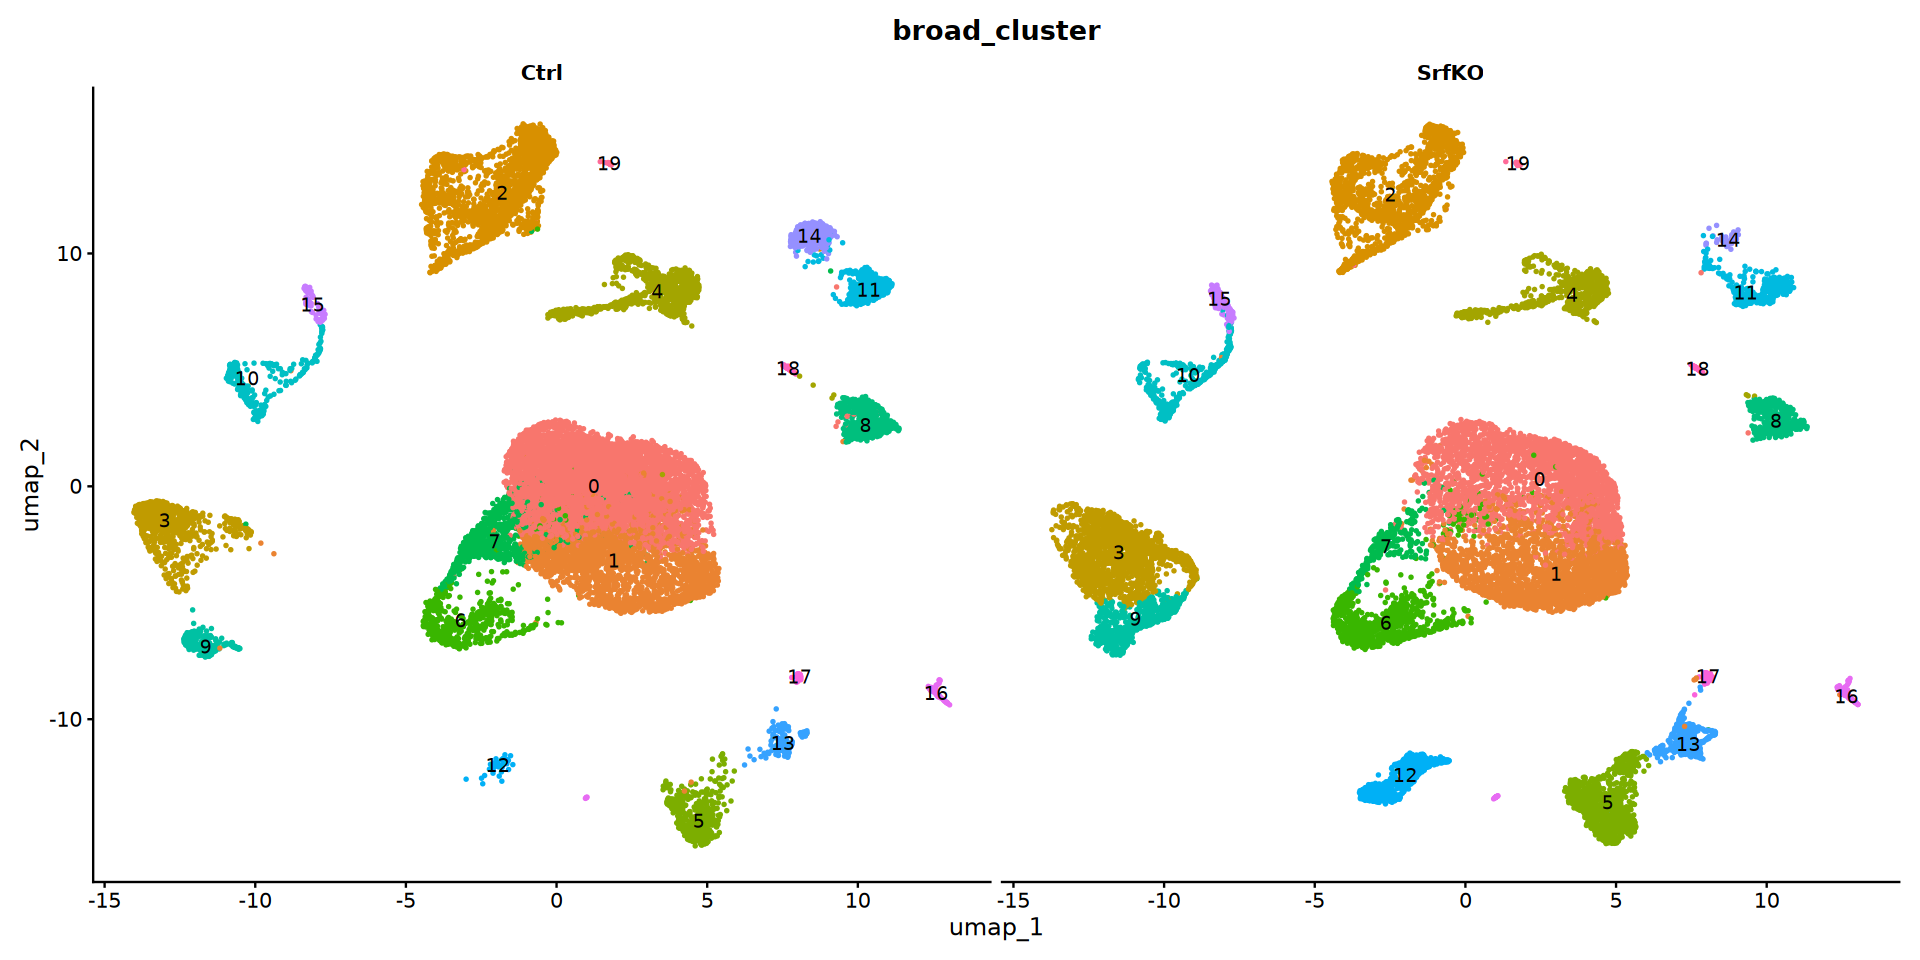

In [112]:
saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

DimPlot(Adult_Srfflox_SrfKO, group.by="broad_cluster", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=TRUE, split.by="genotype"
       )+NoLegend()

options(saved) # restore old settings

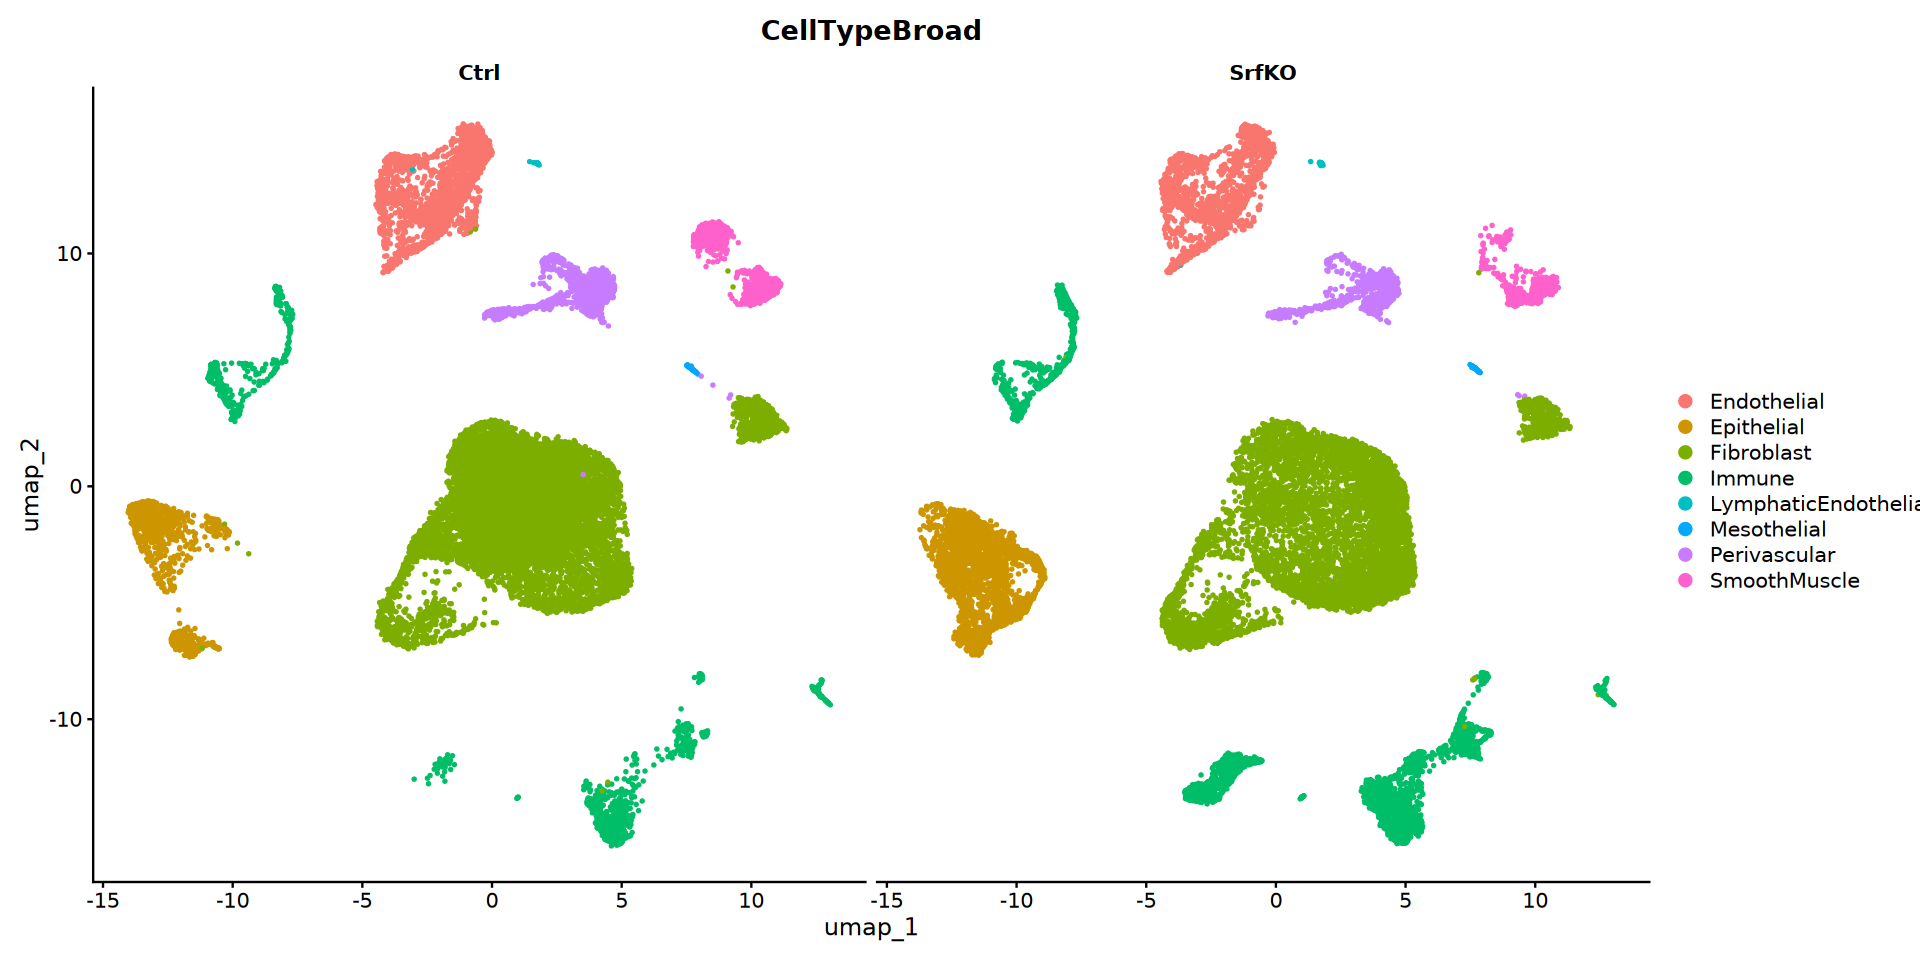

In [113]:
saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

Adult_Srfflox_SrfKO_tmp <- Adult_Srfflox_SrfKO
Idents(Adult_Srfflox_SrfKO_tmp) <- Adult_Srfflox_SrfKO_tmp$broad_cluster

DimPlot(Adult_Srfflox_SrfKO_tmp, group.by="CellTypeBroad", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=FALSE, split.by="genotype"
       )

options(saved) # restore old settings

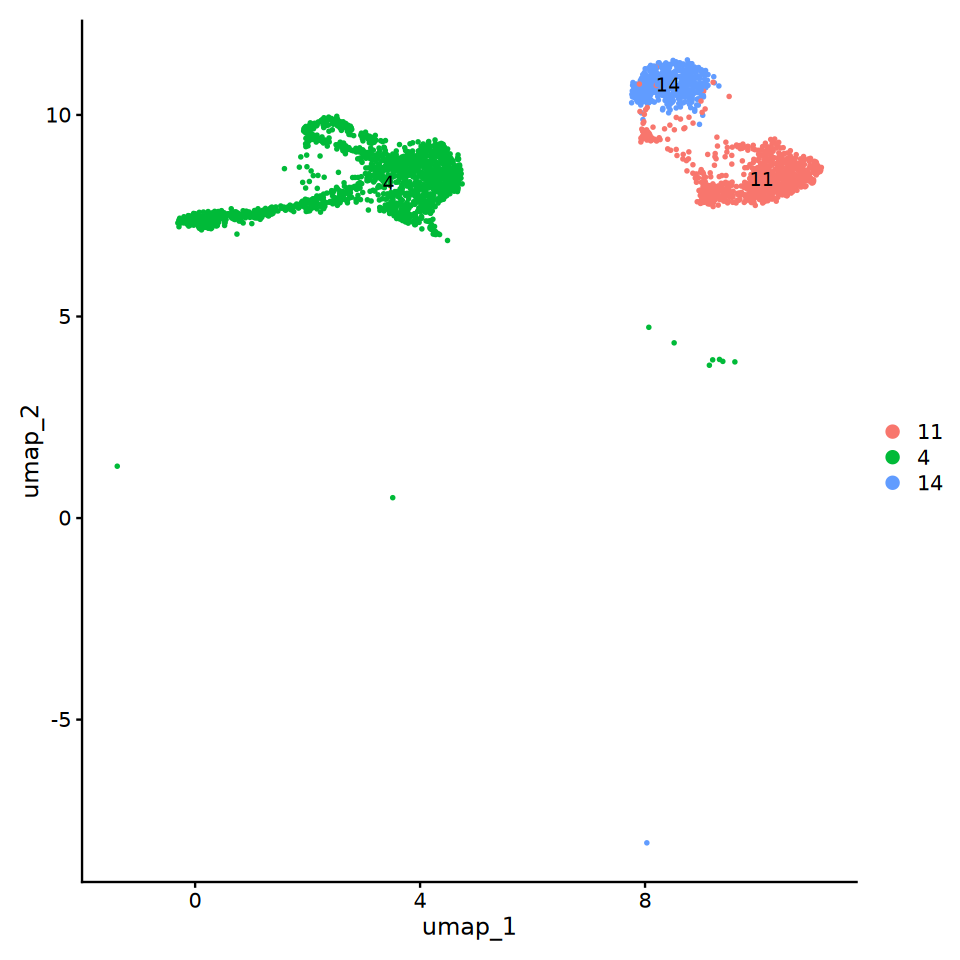

In [114]:
Idents(Adult_Srfflox_SrfKO_tmp) <- Adult_Srfflox_SrfKO_tmp$broad_cluster

SM_PV_cells <- WhichCells(Adult_Srfflox_SrfKO_tmp, idents = c(4,11,14))

saved <- options(repr.plot.width = 8, repr.plot.height = 8) # Make the plots bigger from here on out, save old options
DimPlot(object = Adult_Srfflox_SrfKO_tmp, cells = SM_PV_cells, reduction = "umap", label = T)
options(saved) # restore old settings

In [115]:
#Subset clusters 4, 11, 14 only

Idents(Adult_Srfflox_SrfKO_tmp) <- Adult_Srfflox_SrfKO_tmp$broad_cluster

Adult_Srfflox_SrfKO_SM_PV <- subset(Adult_Srfflox_SrfKO_tmp, idents=c(4,11,14));
Adult_Srfflox_SrfKO_SM_PV


An object of class Seurat 
26486 features across 3107 samples within 1 assay 
Active assay: RNA (26486 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.rpca, umap

In [116]:
table(Adult_Srfflox_SrfKO_SM_PV$broad_cluster,Adult_Srfflox_SrfKO_SM_PV$Sample);

    
     Ctrl1 Ctrl2 SrfKO1 SrfKO2
  4    664   337    360    375
  11   268   174    104    351
  14   356    85      1     32

In [117]:
table(Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad,Adult_Srfflox_SrfKO_SM_PV$genotype);

              
               Ctrl SrfKO
  Perivascular 1001   735
  SmoothMuscle  883   488

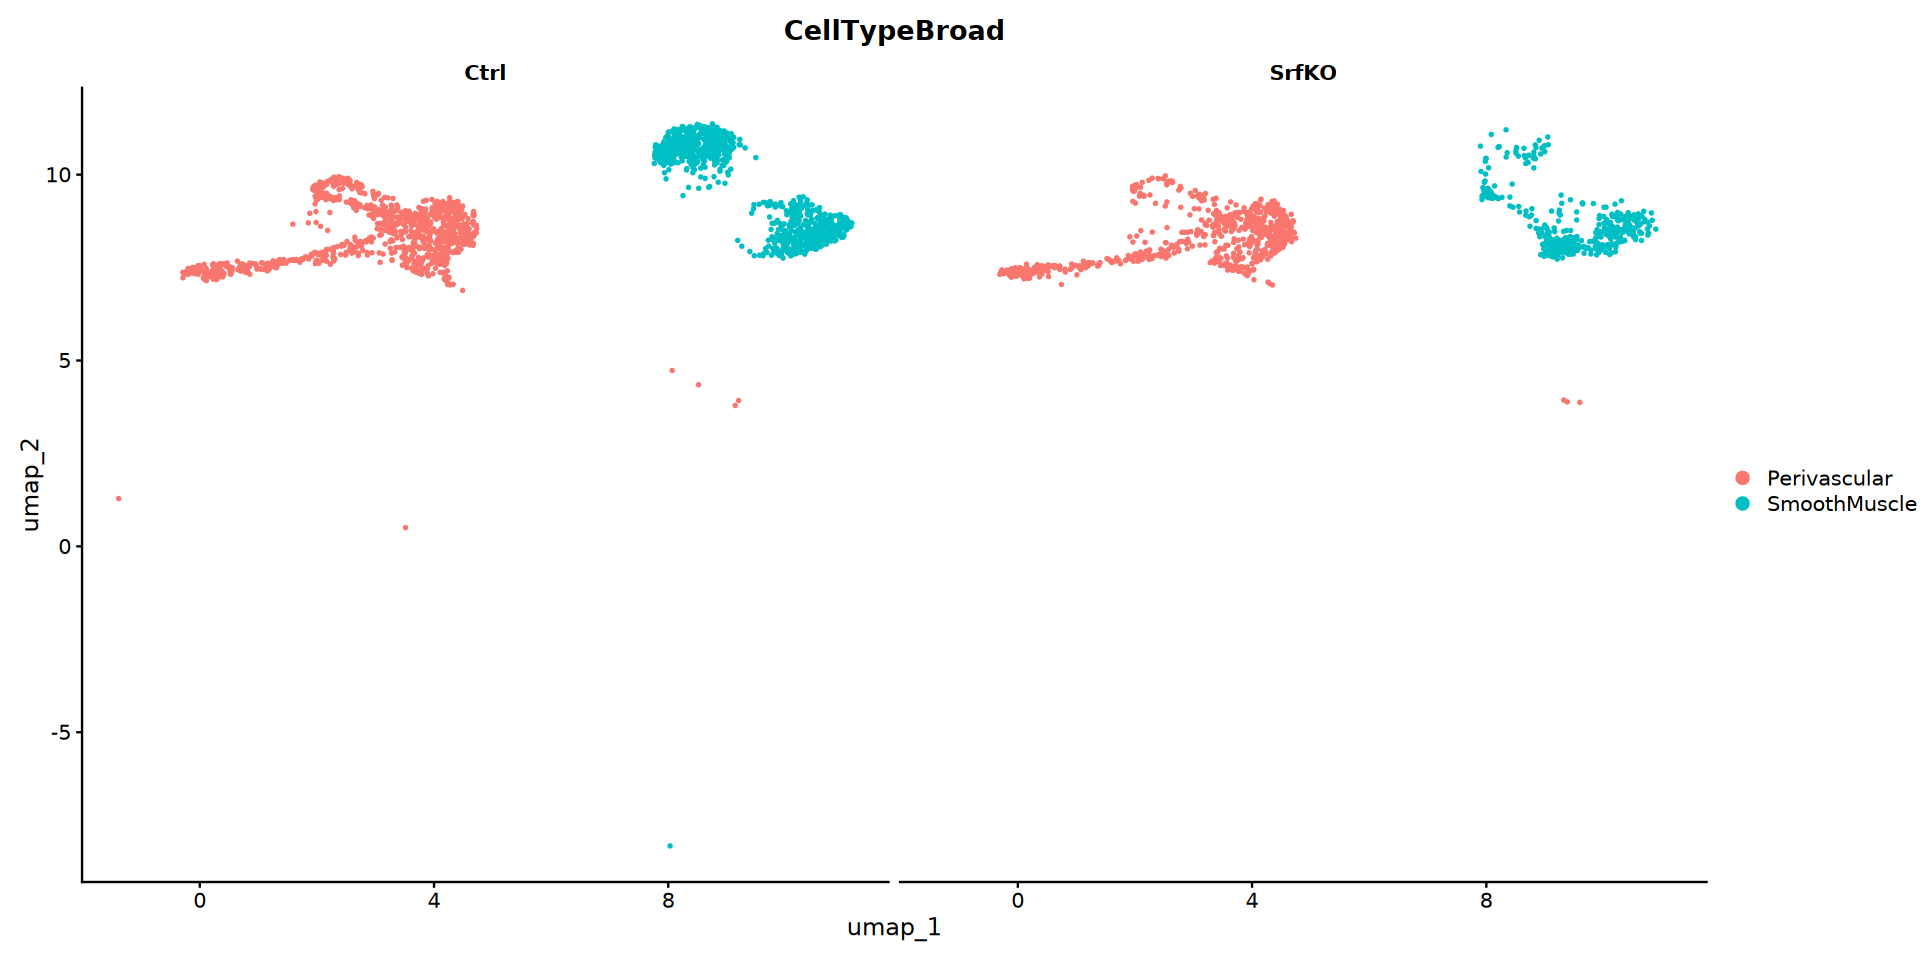

In [118]:
saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

DimPlot(Adult_Srfflox_SrfKO_SM_PV, group.by="CellTypeBroad", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=FALSE, split.by="genotype"
       )

options(saved) # restore old settings

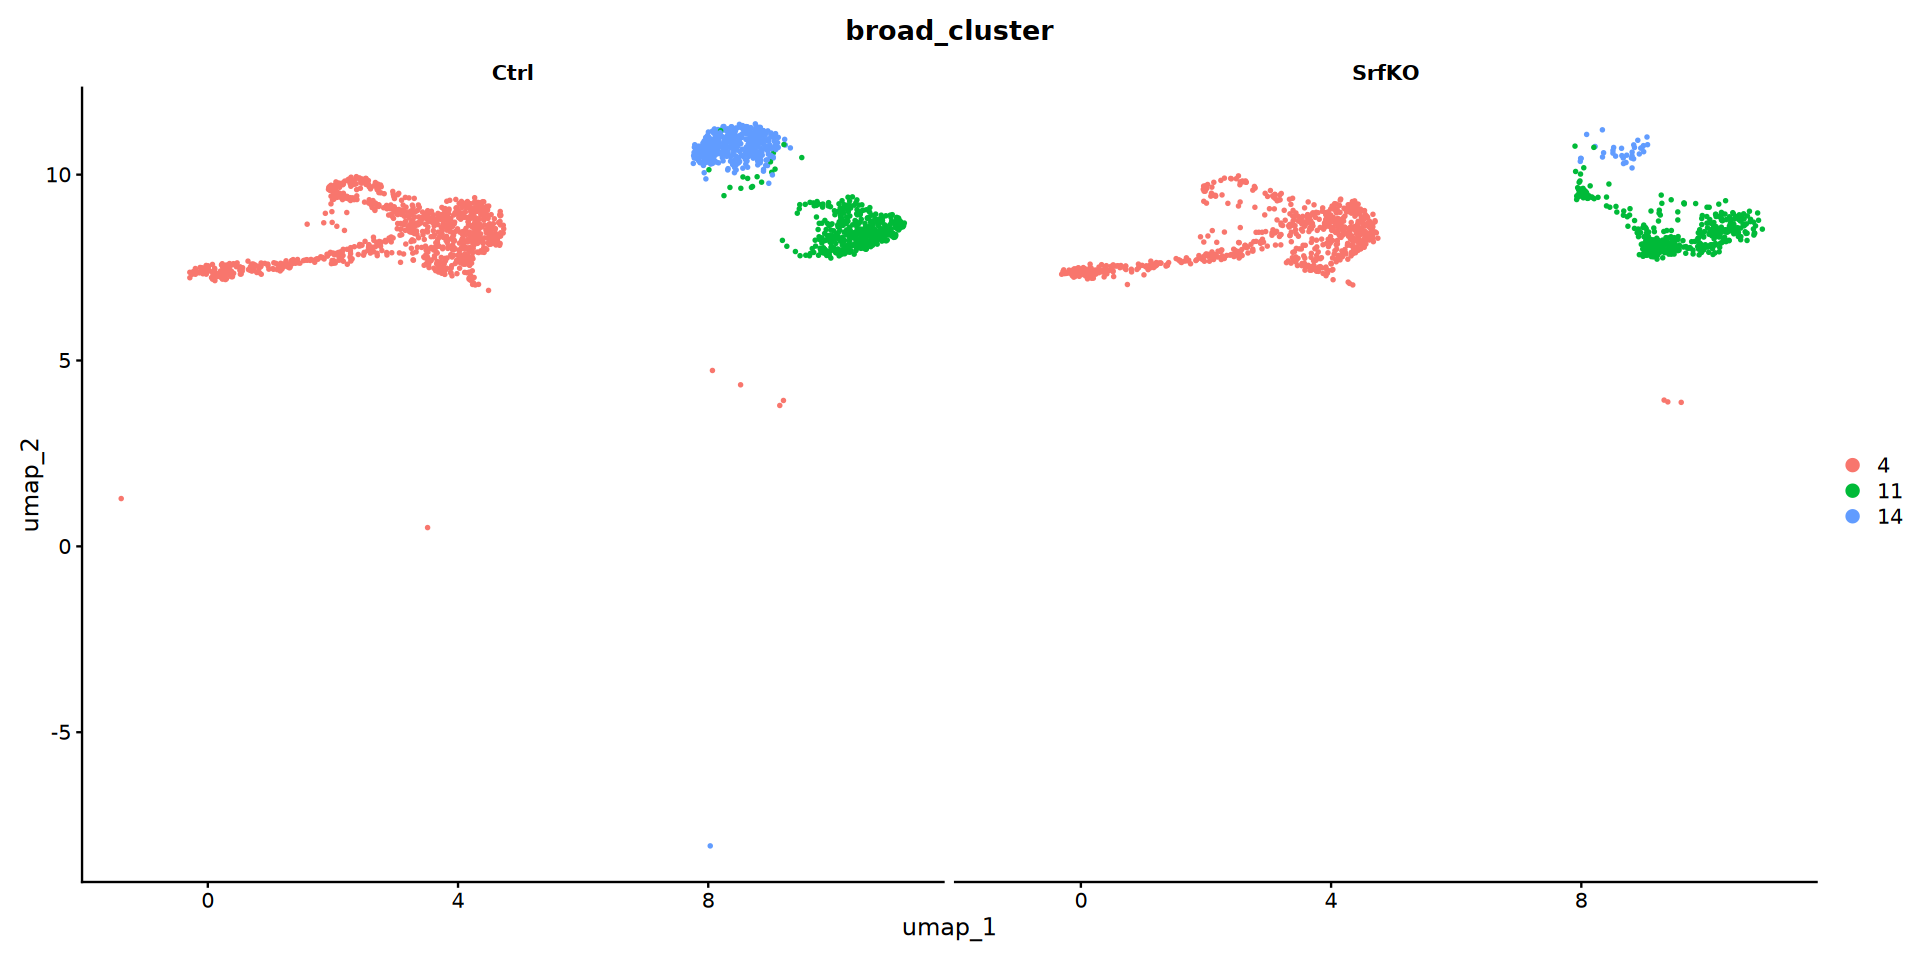

In [119]:
saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

DimPlot(Adult_Srfflox_SrfKO_SM_PV, group.by="broad_cluster", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=FALSE, split.by="genotype"
       )

options(saved) # restore old settings

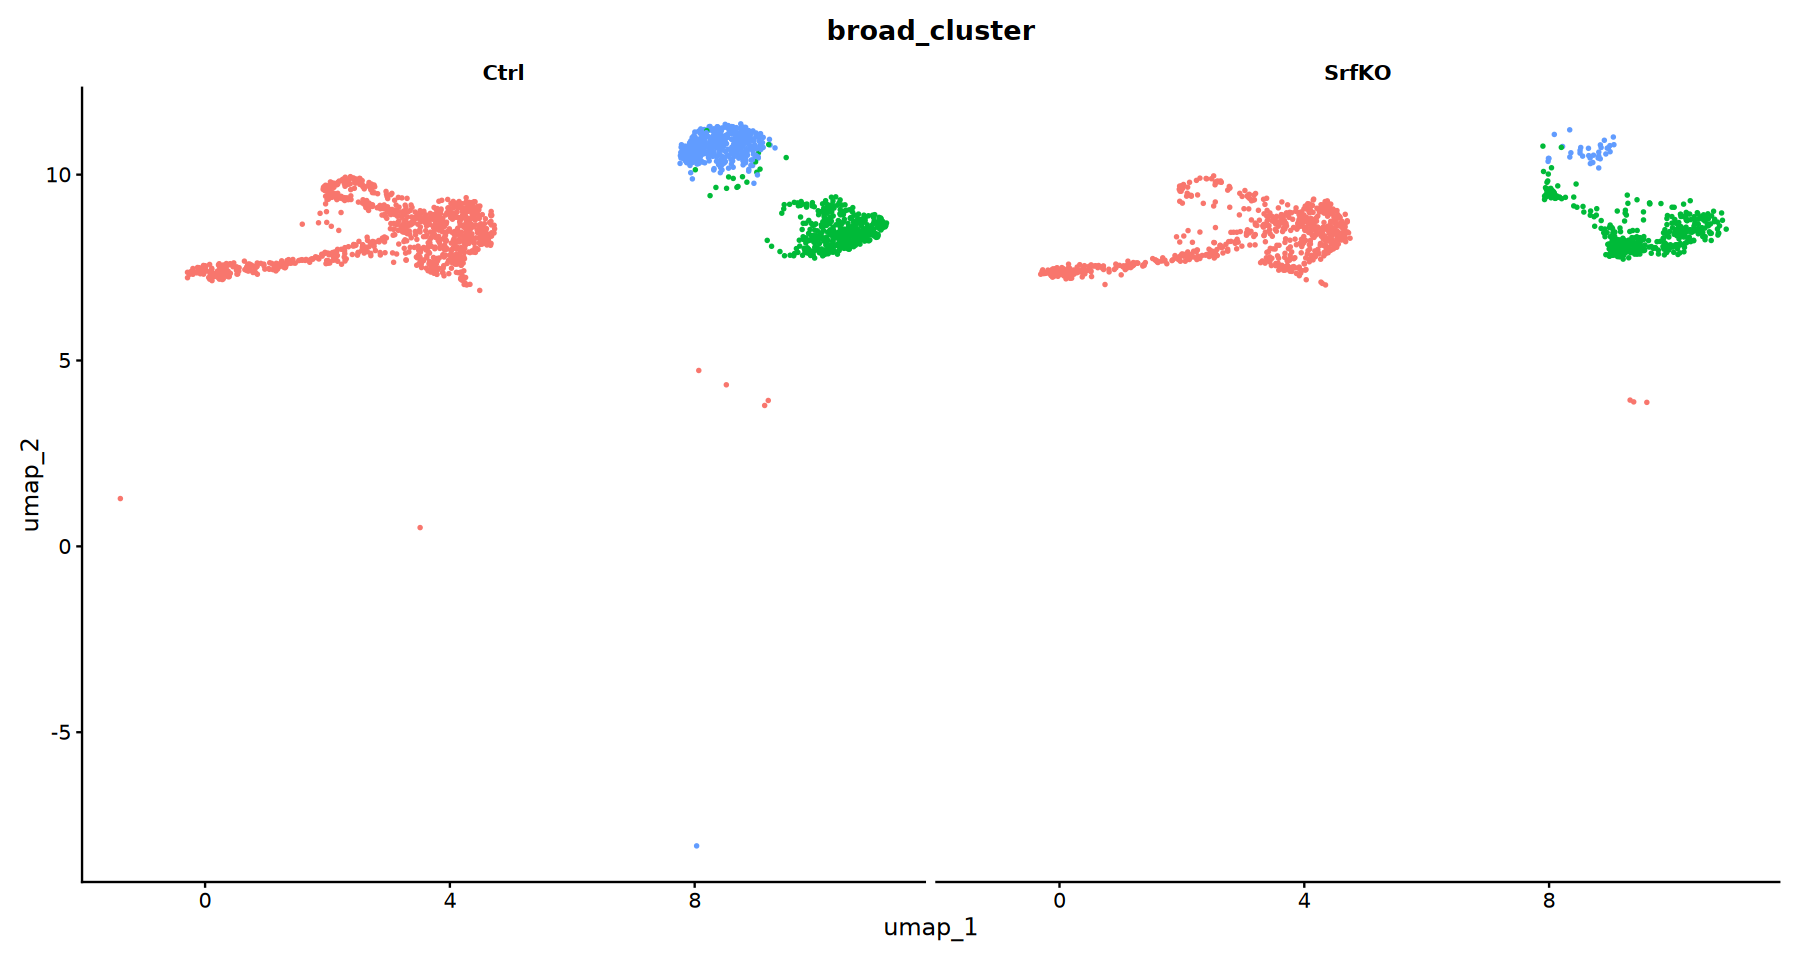

In [120]:
saved <- options(repr.plot.width = 15, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

DimPlot(Adult_Srfflox_SrfKO_SM_PV, group.by="broad_cluster", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=FALSE, split.by="genotype"
            )+NoLegend();

options(saved) # restore old settings

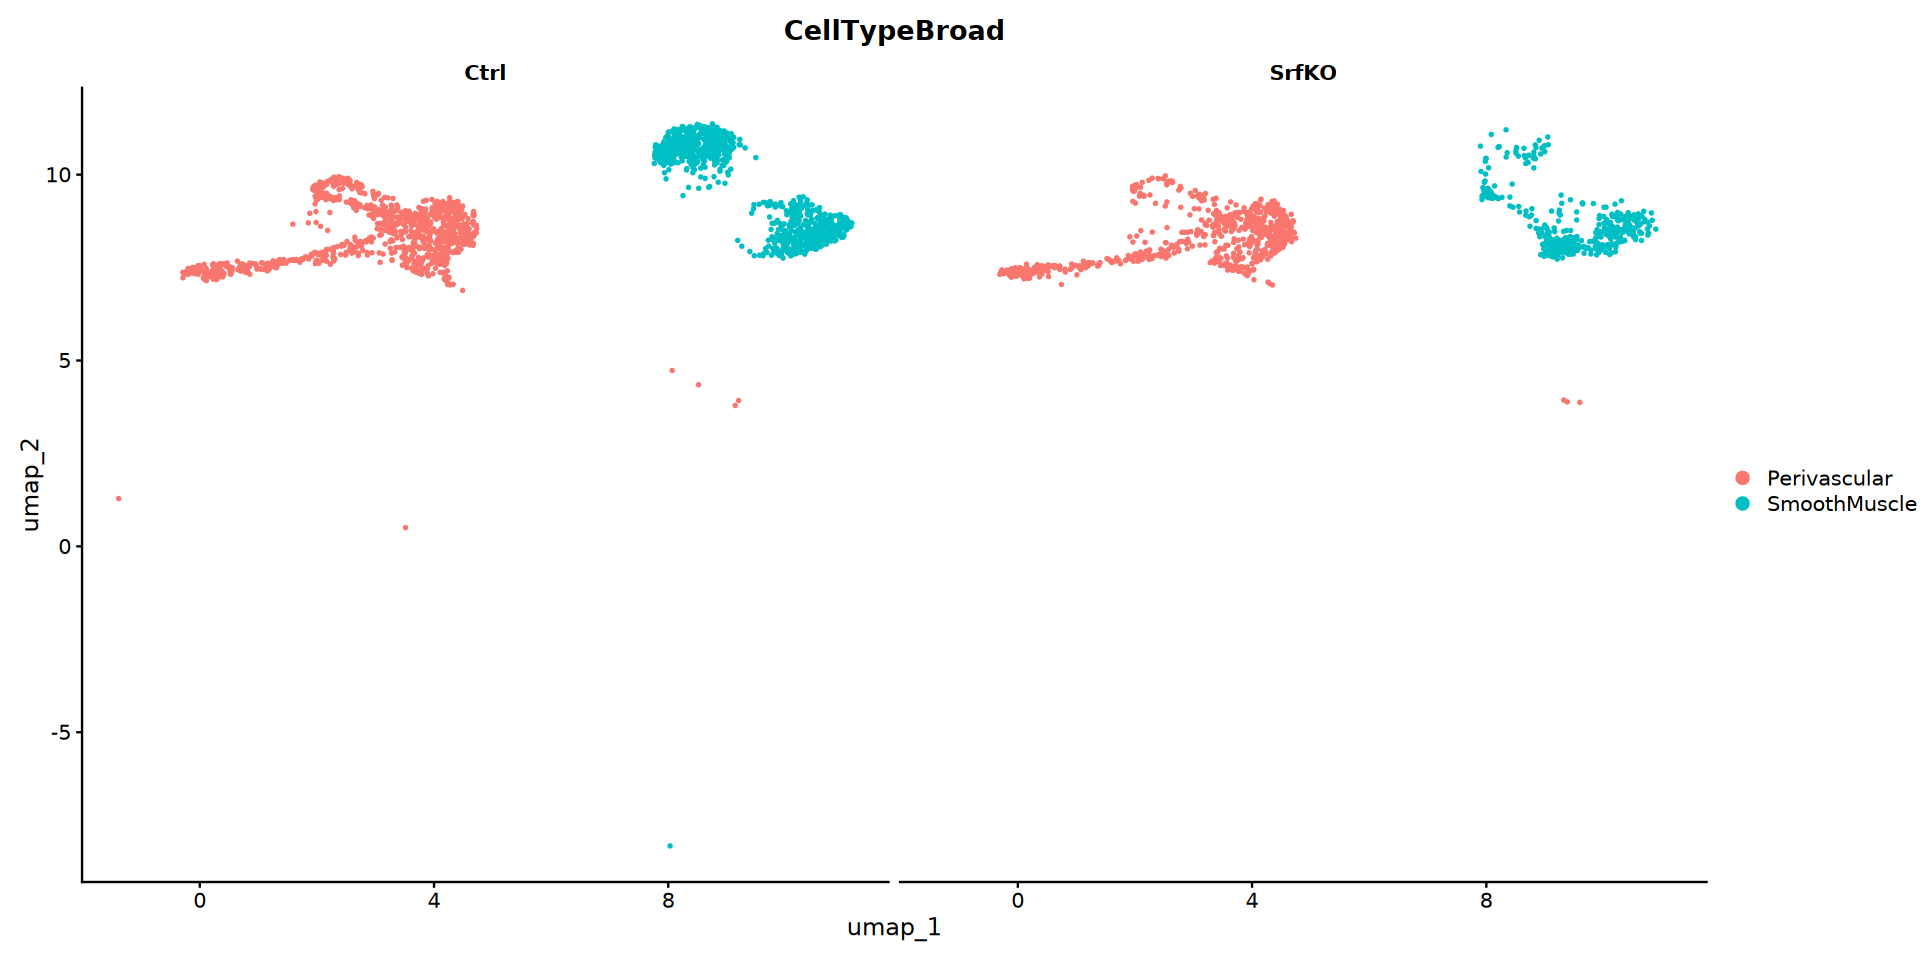

In [121]:
saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

DimPlot(Adult_Srfflox_SrfKO_SM_PV, group.by="CellTypeBroad", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=FALSE, split.by="genotype"
       )

options(saved) # restore old settings

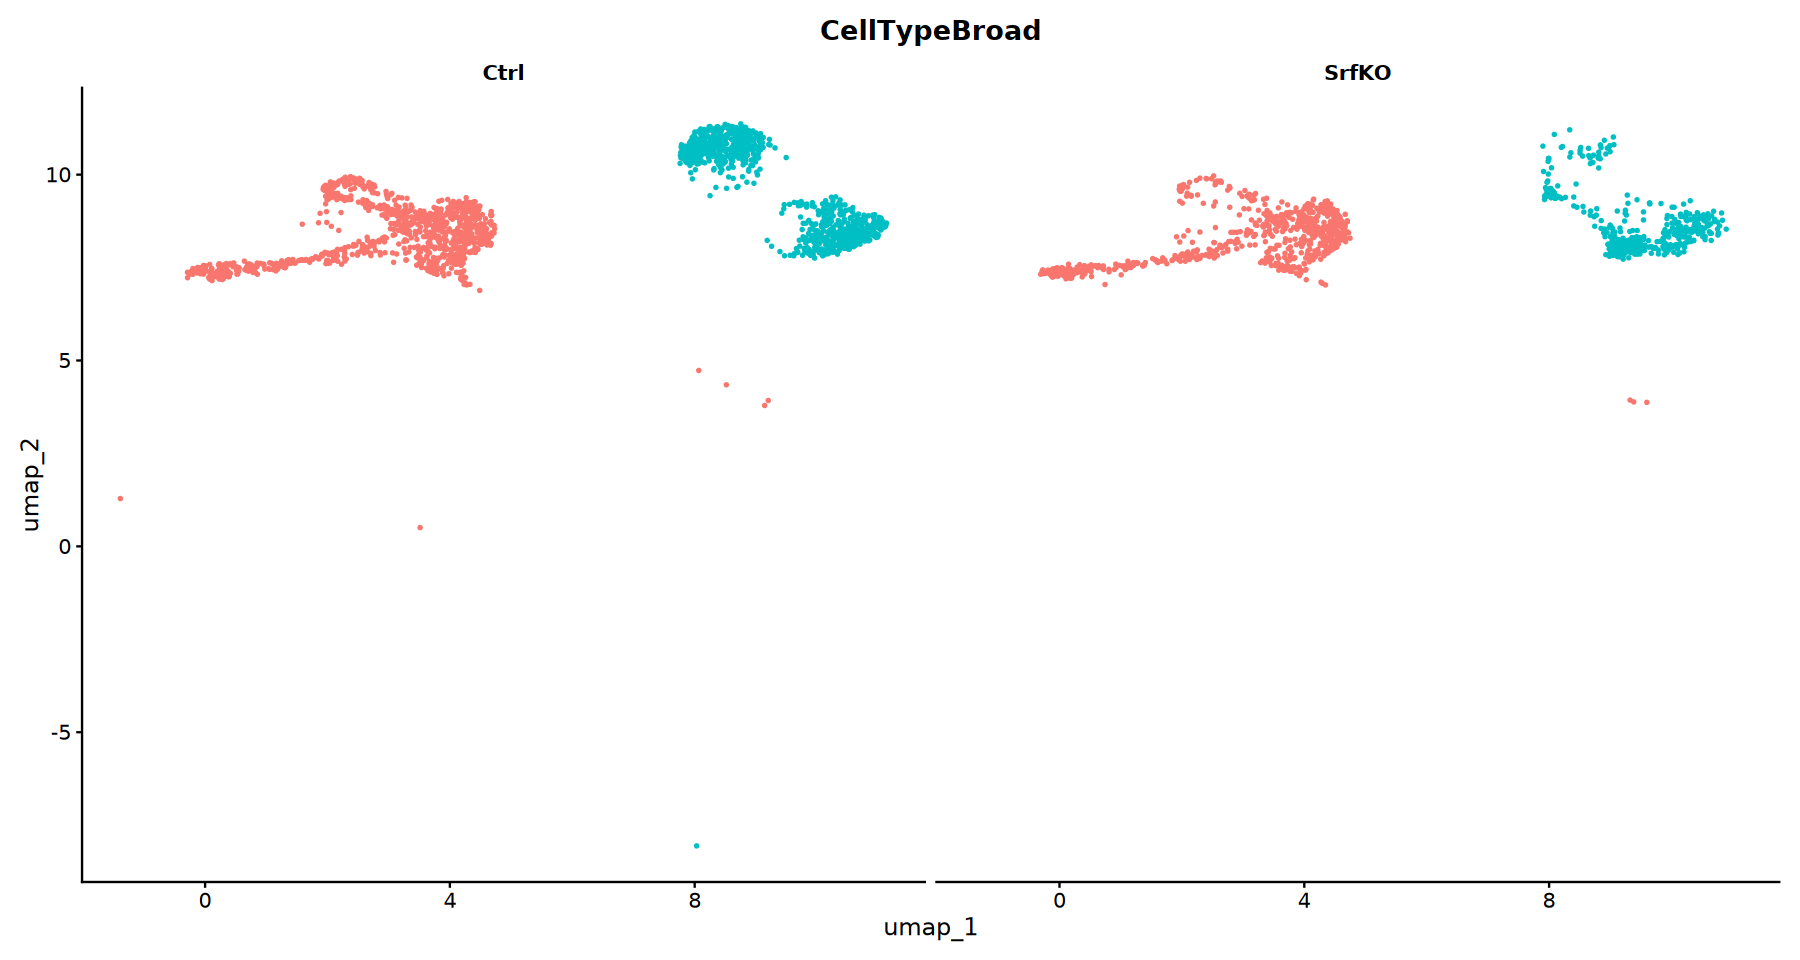

In [122]:
saved <- options(repr.plot.width = 15, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

DimPlot(Adult_Srfflox_SrfKO_SM_PV, group.by="CellTypeBroad", pt.size=0.5, reduction='umap', shuffle=TRUE,
        label=FALSE, split.by="genotype"
            )+NoLegend();

options(saved) # restore old settings

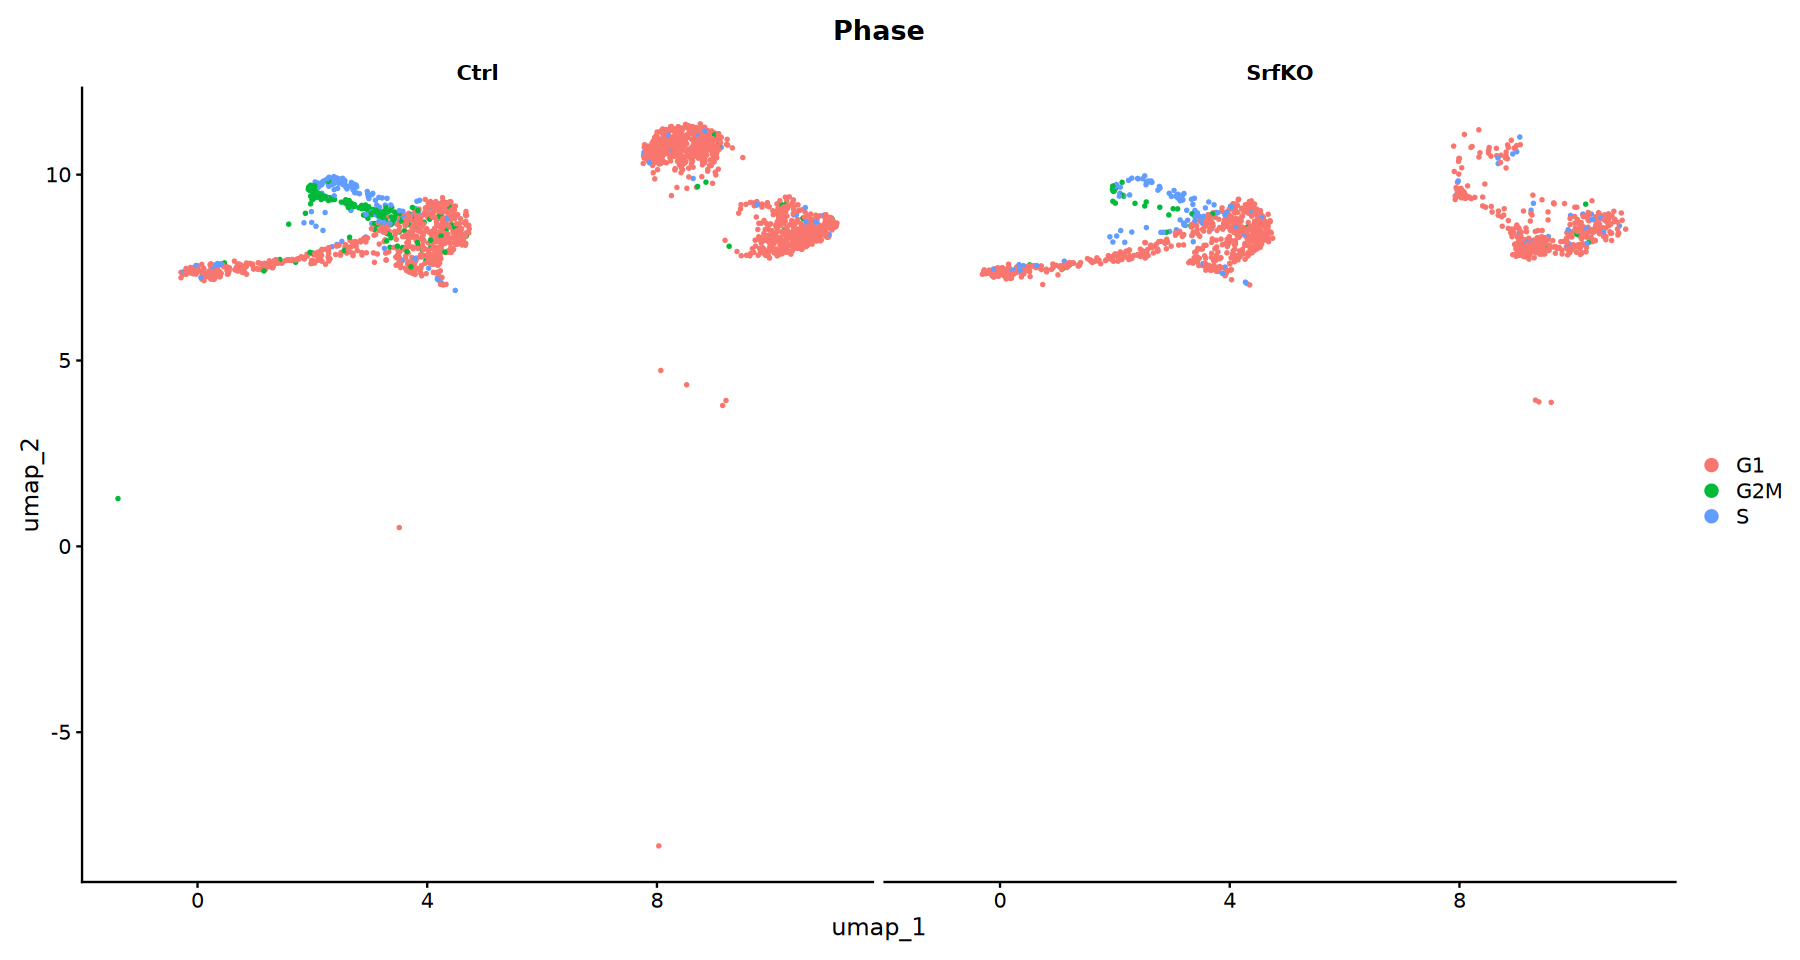

In [169]:
saved <- options(repr.plot.width = 15, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

DimPlot(Adult_Srfflox_SrfKO_SM_PV, group.by="Phase", split.by="genotype", pt.size=0.5, reduction='umap', shuffle=TRUE)

options(saved) # restore old settings

In [170]:
table(Adult_Srfflox_SrfKO_SM_PV$Phase,Adult_Srfflox_SrfKO_SM_PV$genotype);

     
      Ctrl SrfKO
  G1  1512  1050
  G2M  202    32
  S    170   141

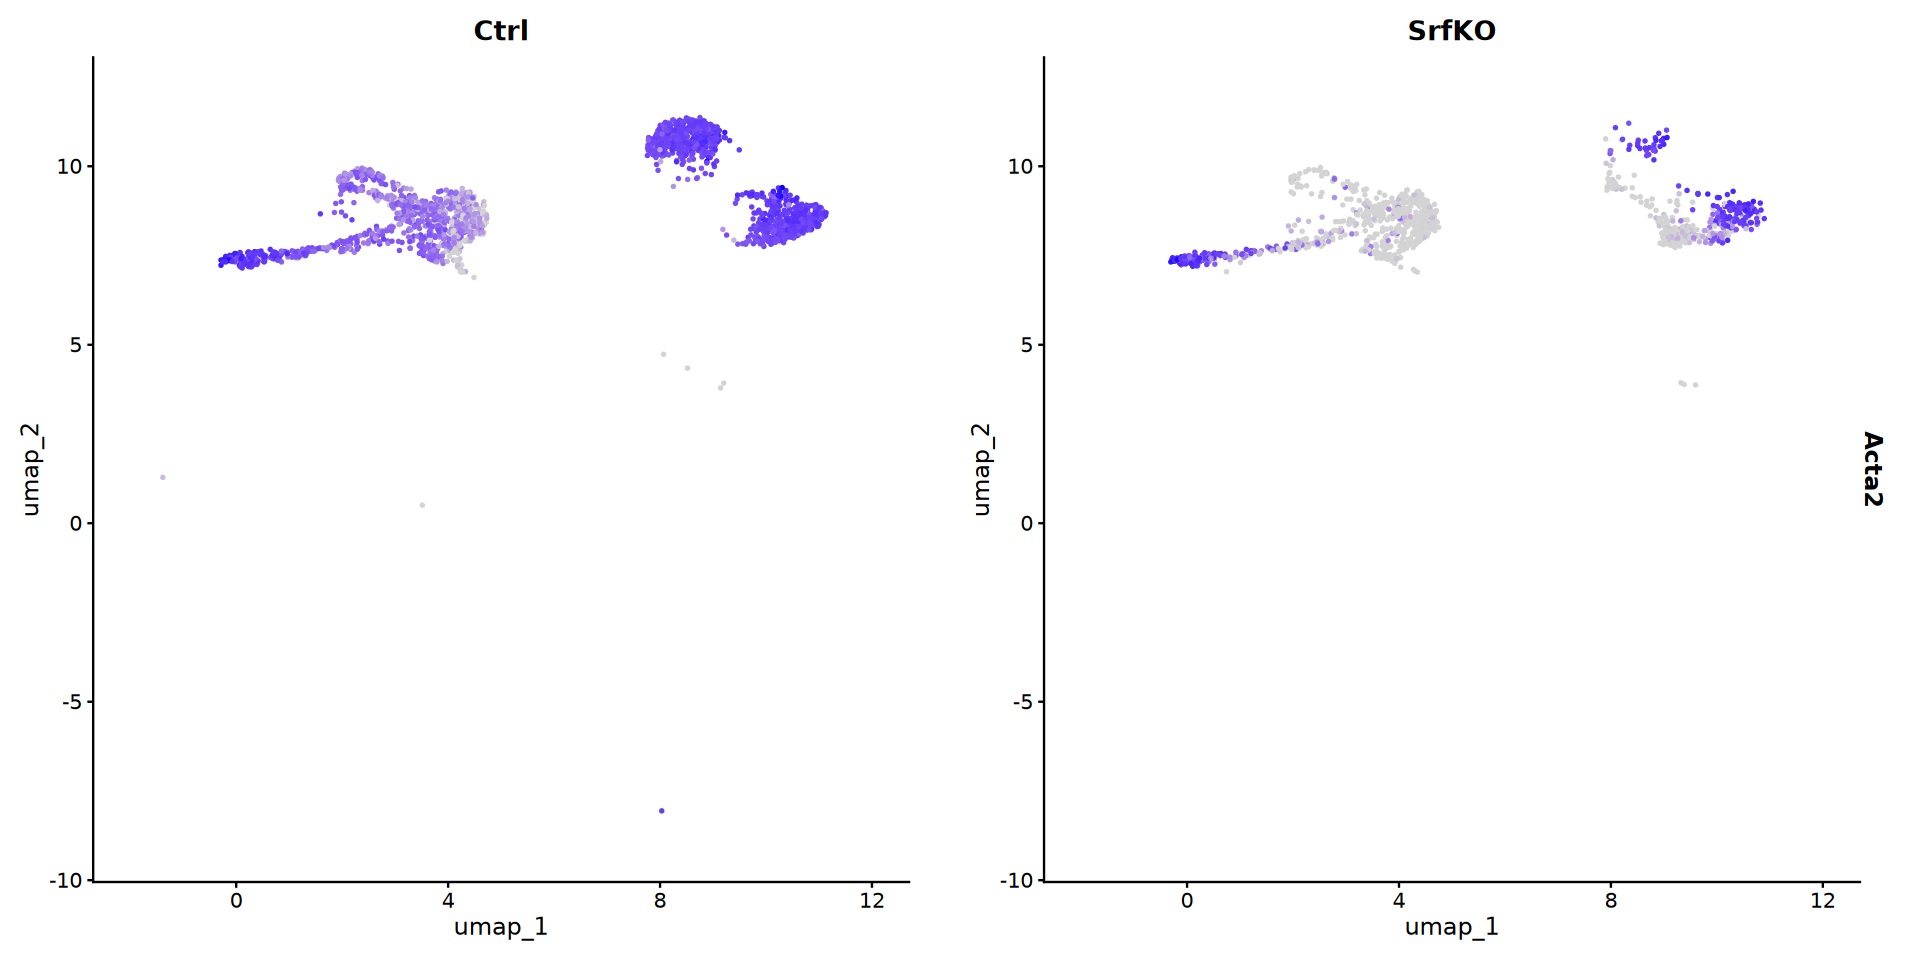

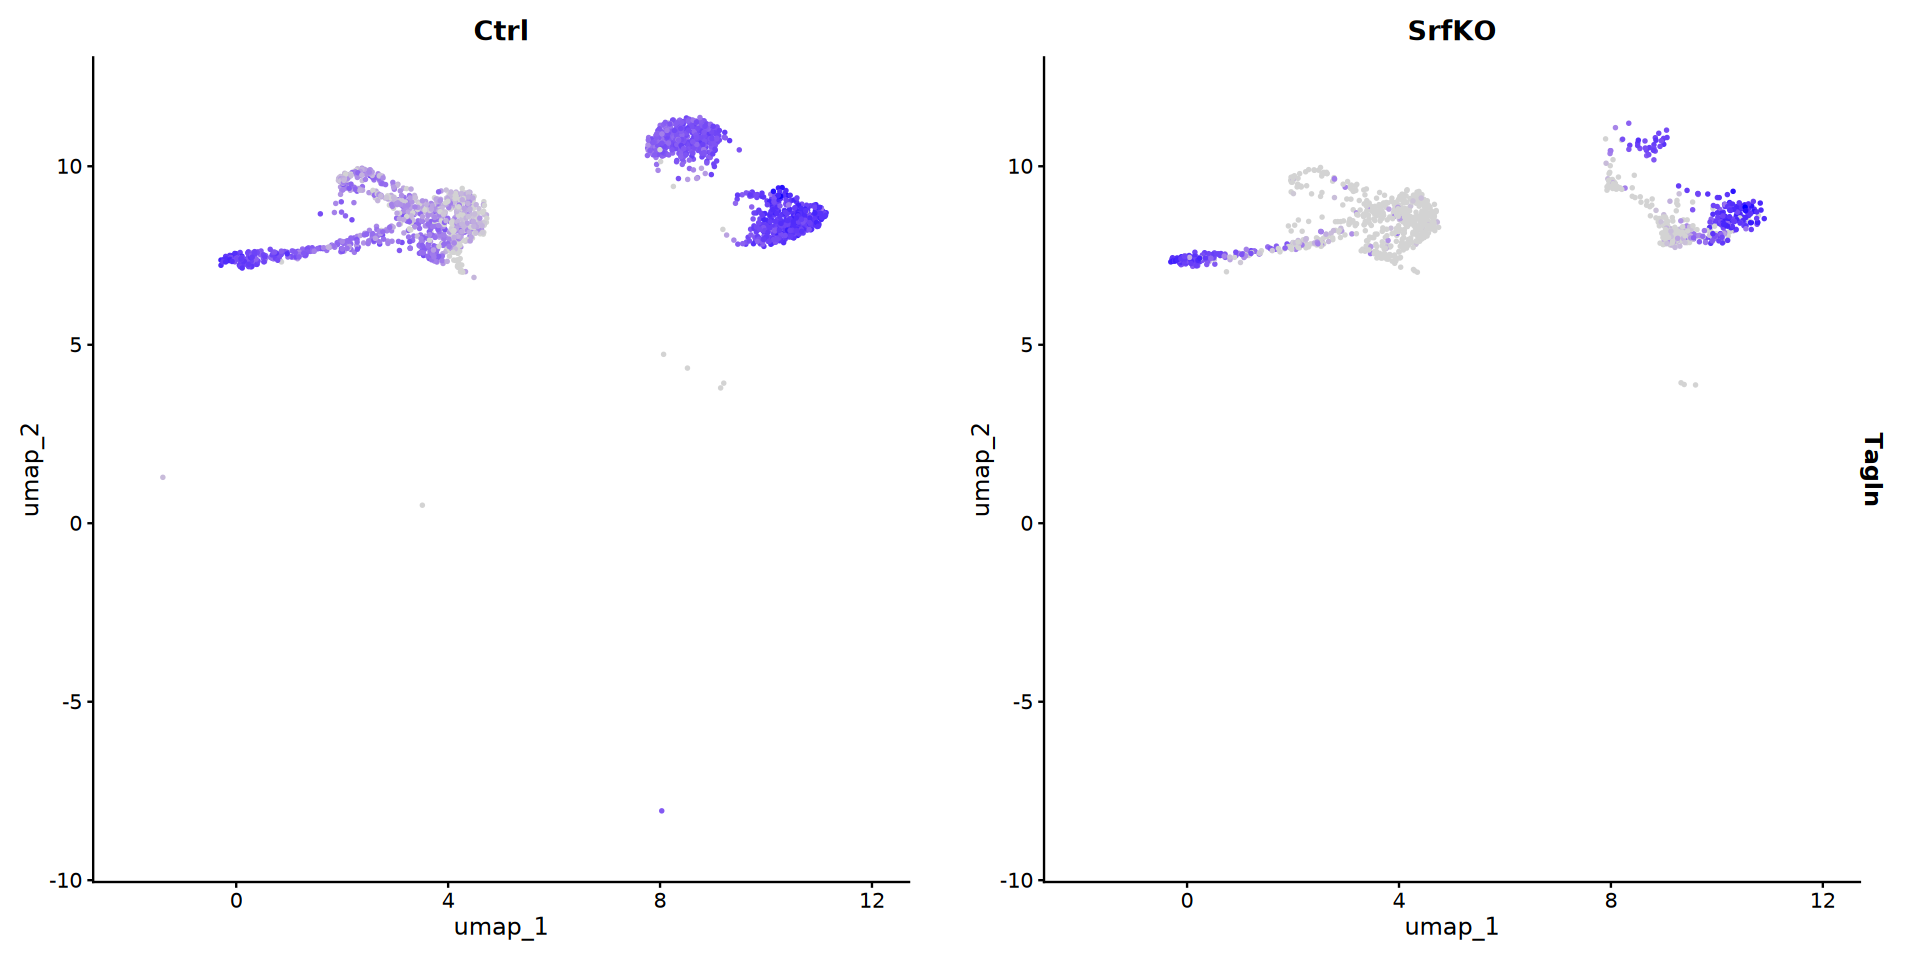

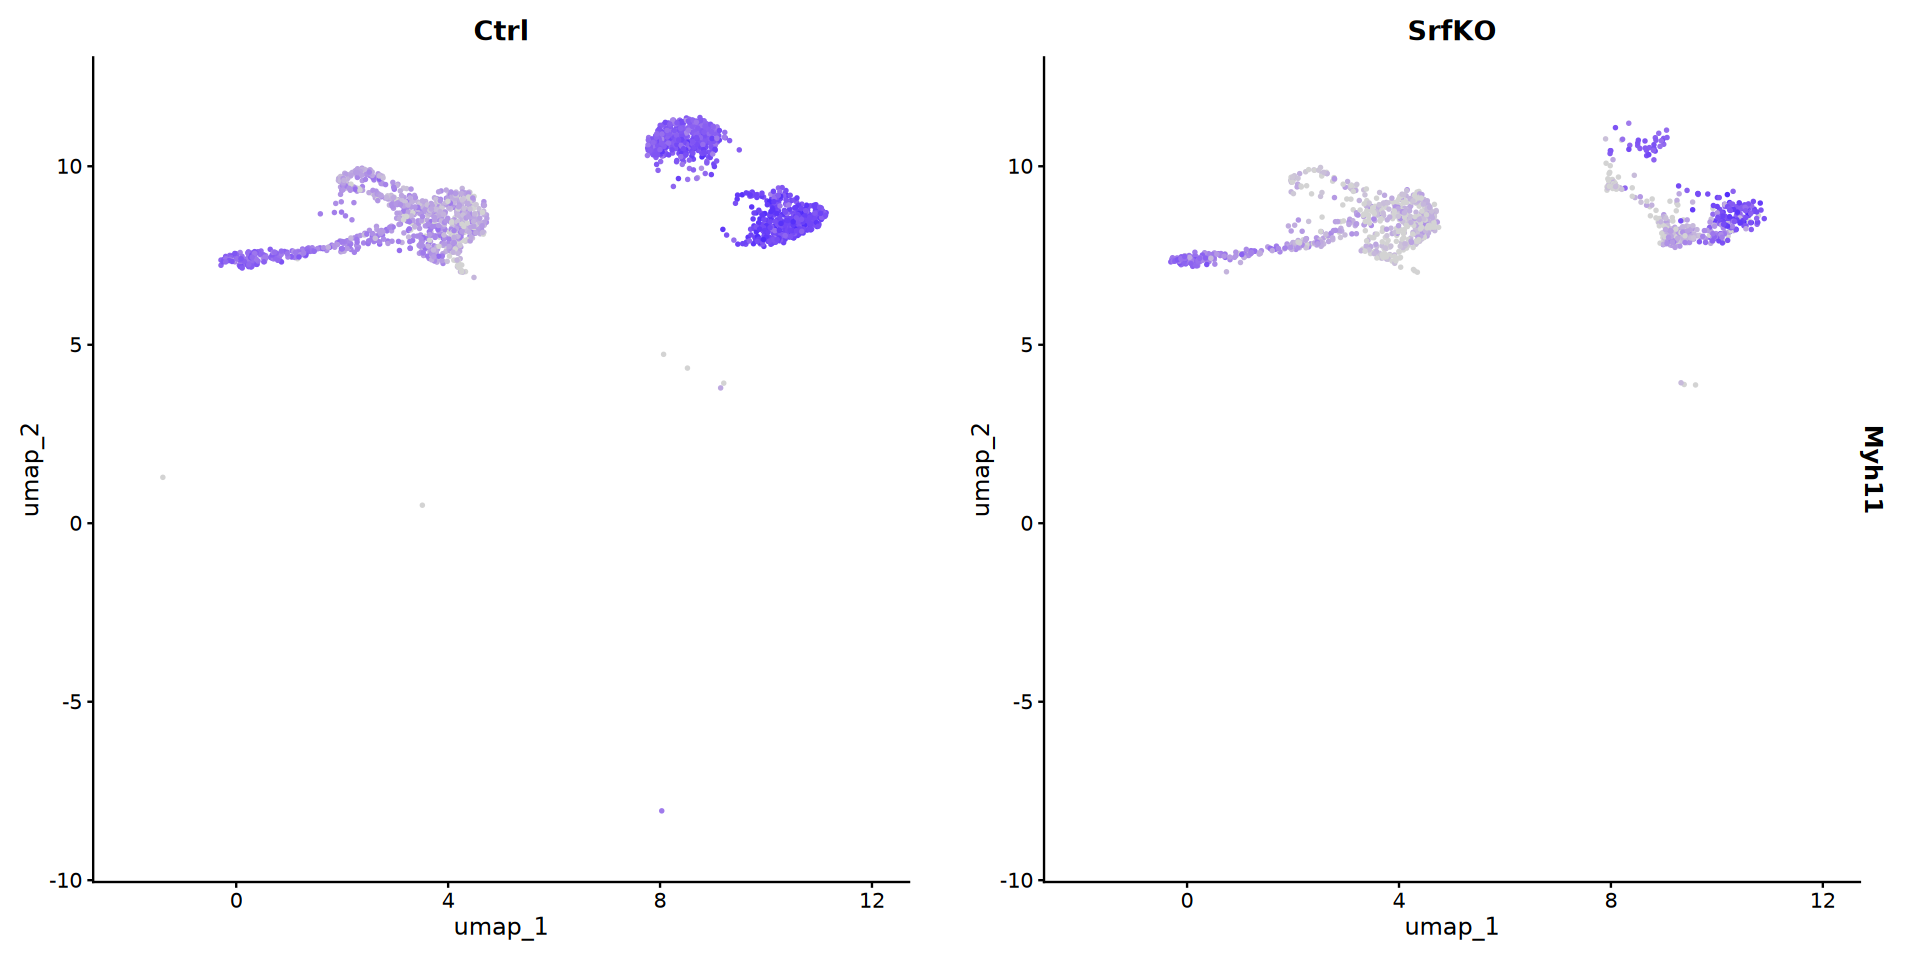

In [123]:
saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

FeaturePlot(Adult_Srfflox_SrfKO_SM_PV, features = c('Acta2'), 
            pt.size=0.5,
            label=FALSE,
            repel = TRUE,
            split.by="genotype")

FeaturePlot(Adult_Srfflox_SrfKO_SM_PV, features = c('Tagln'), 
            pt.size=0.5,
            label=FALSE,
            repel = TRUE,
            split.by="genotype")

FeaturePlot(Adult_Srfflox_SrfKO_SM_PV, features = c('Myh11'), 
            pt.size=0.5,
            label=FALSE,
            repel = TRUE,
            split.by="genotype")

options(saved) # restore old settings

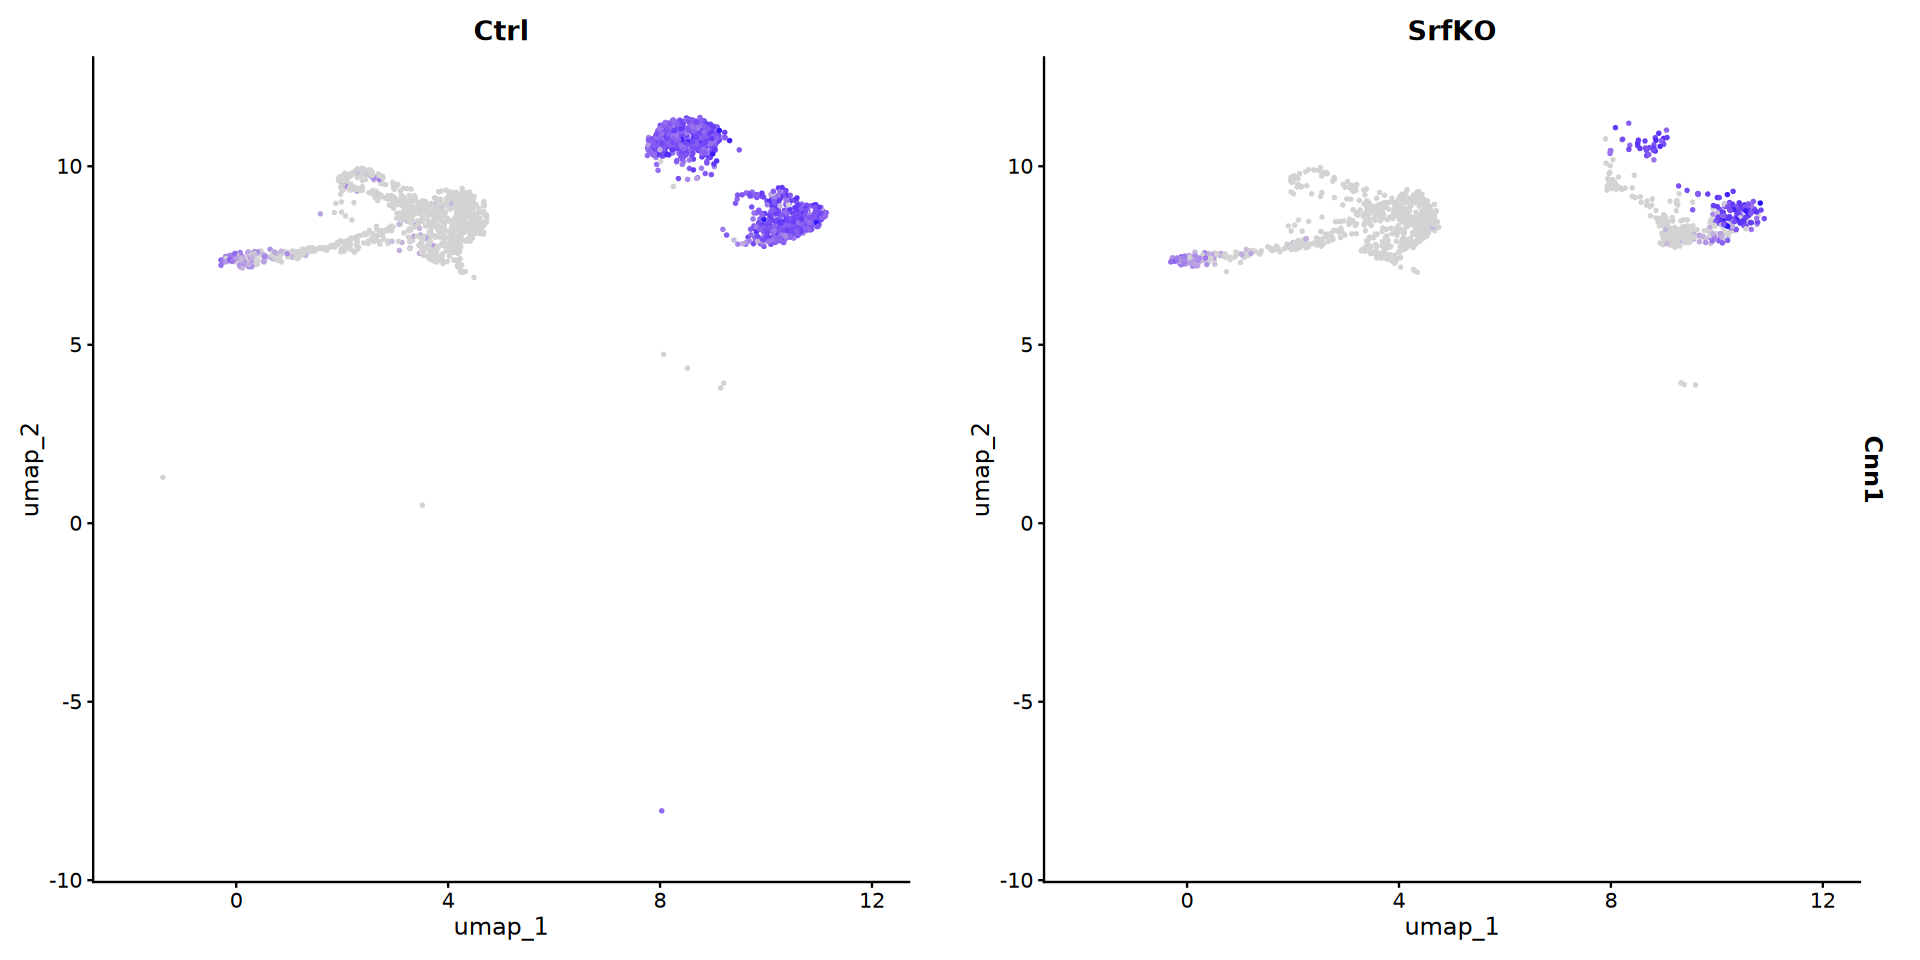

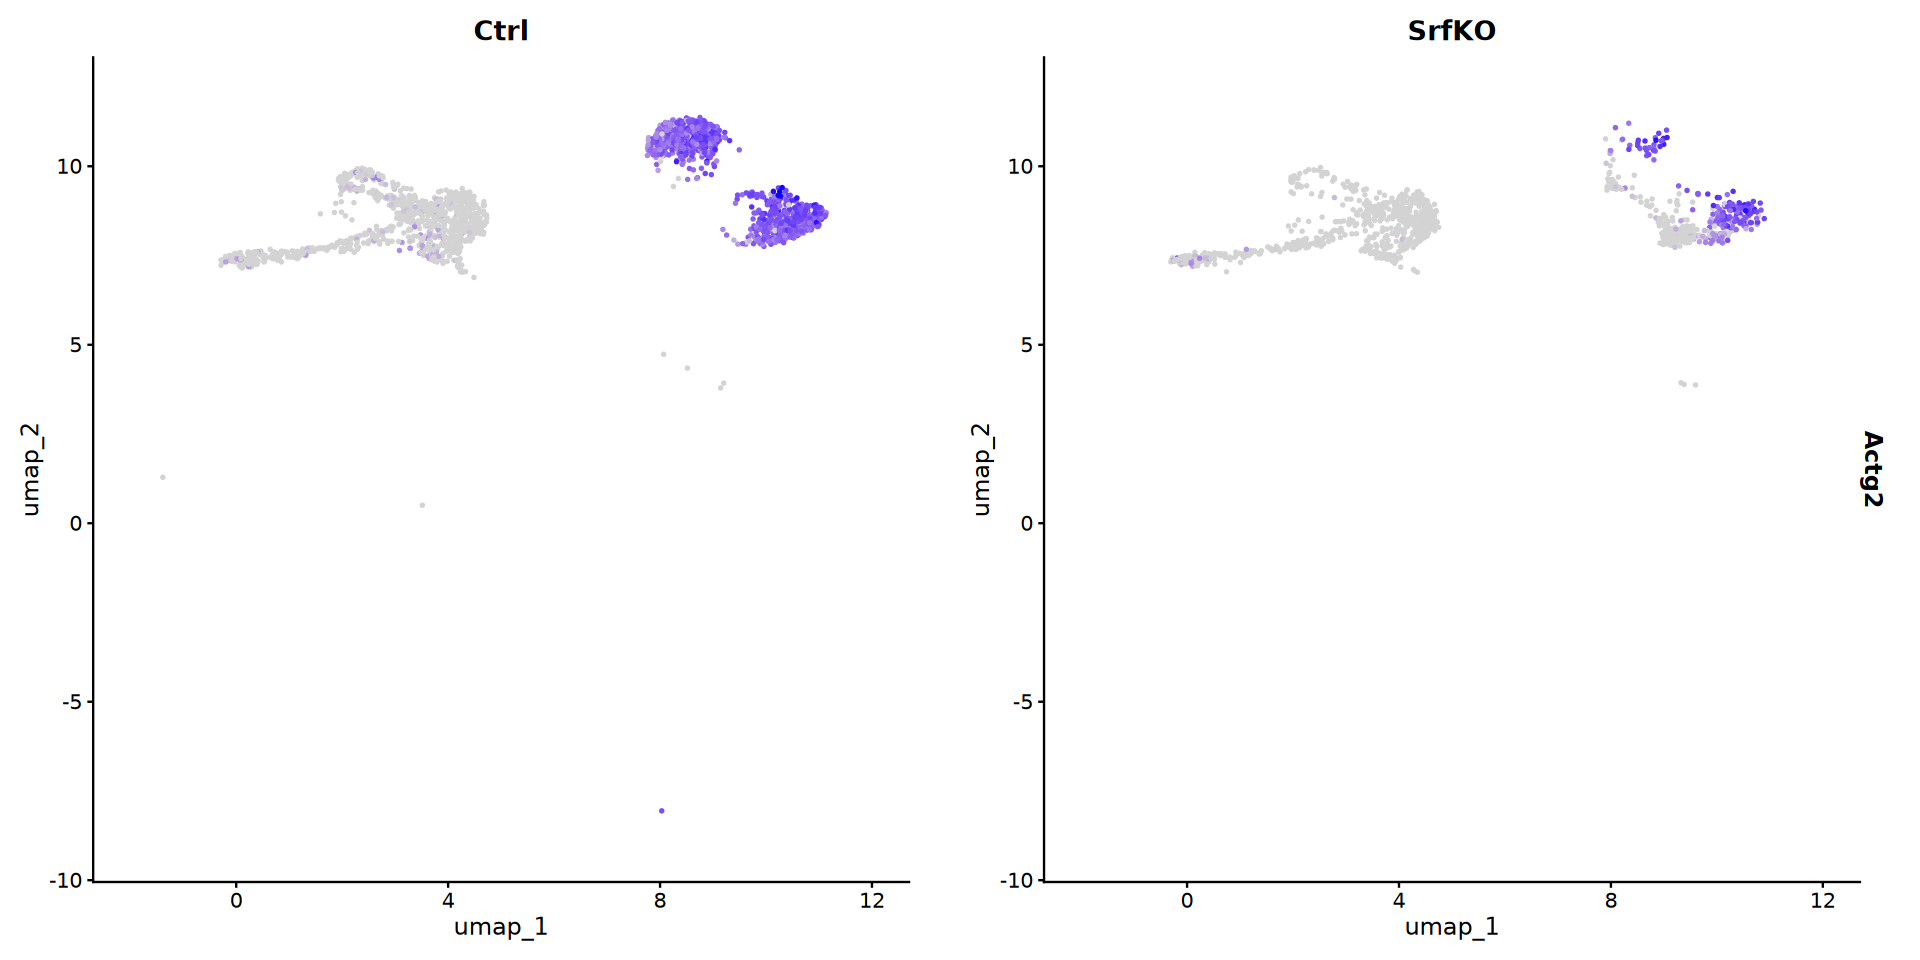

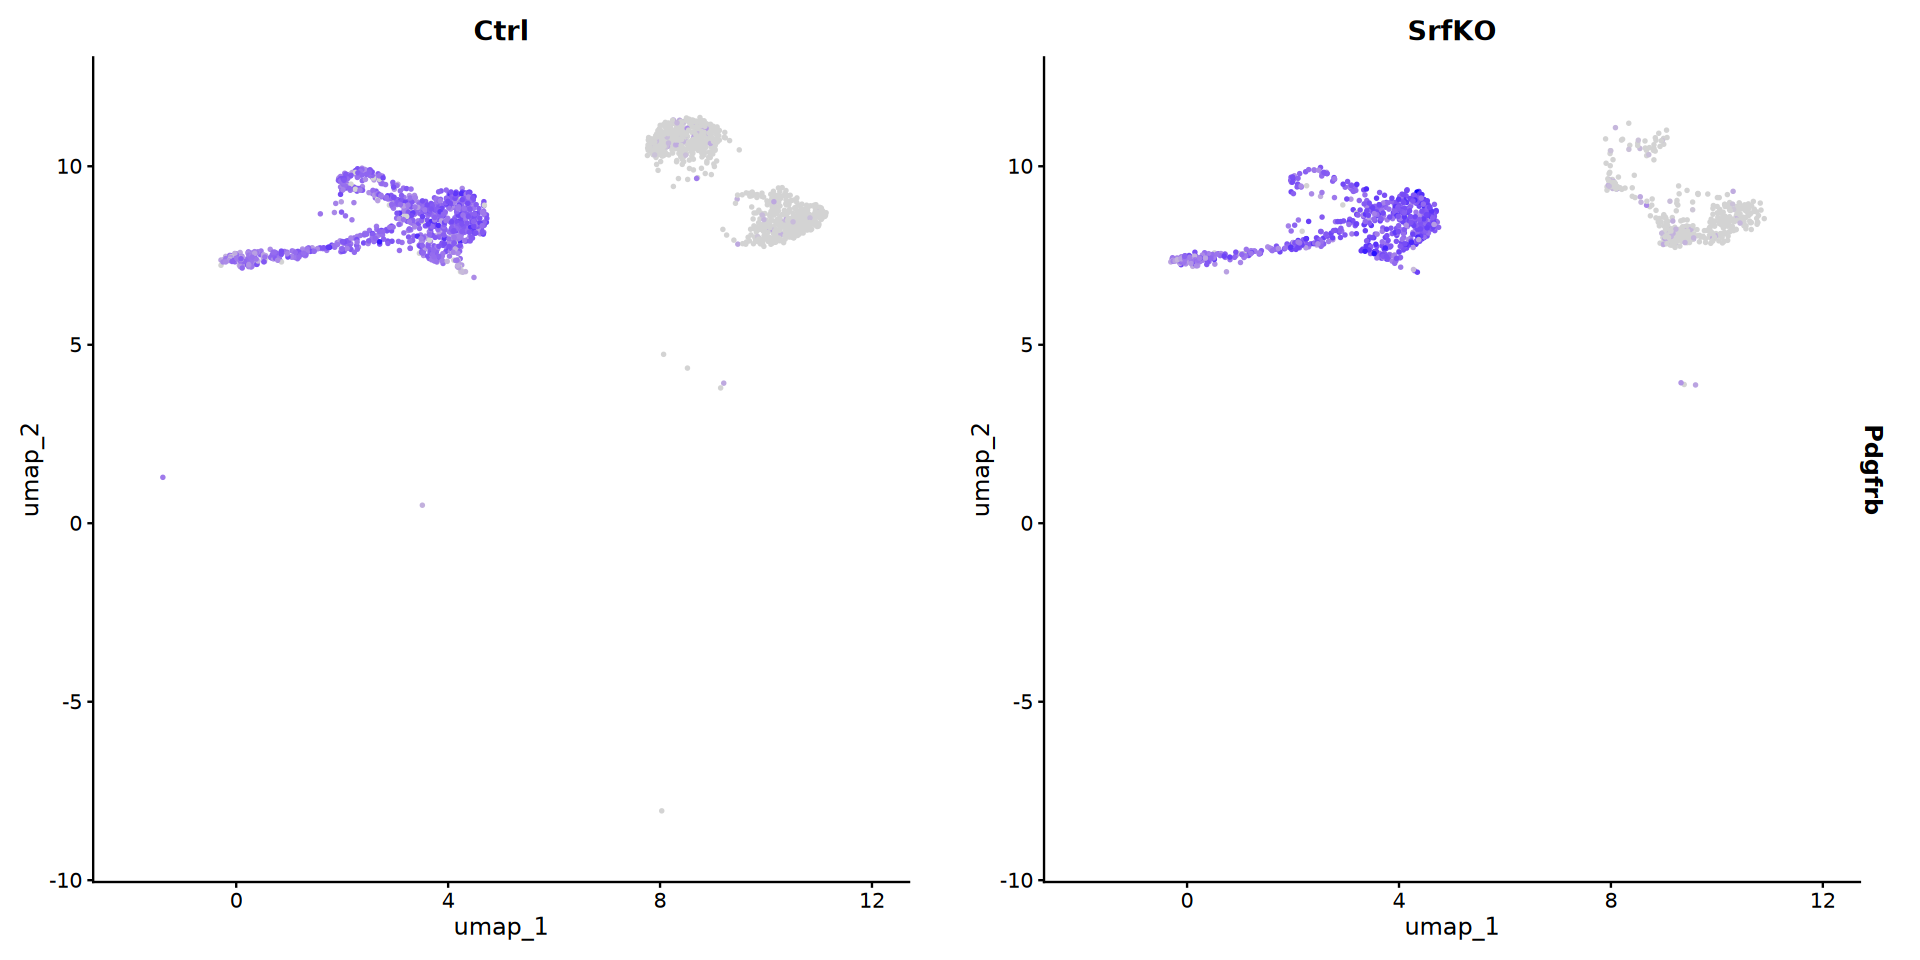

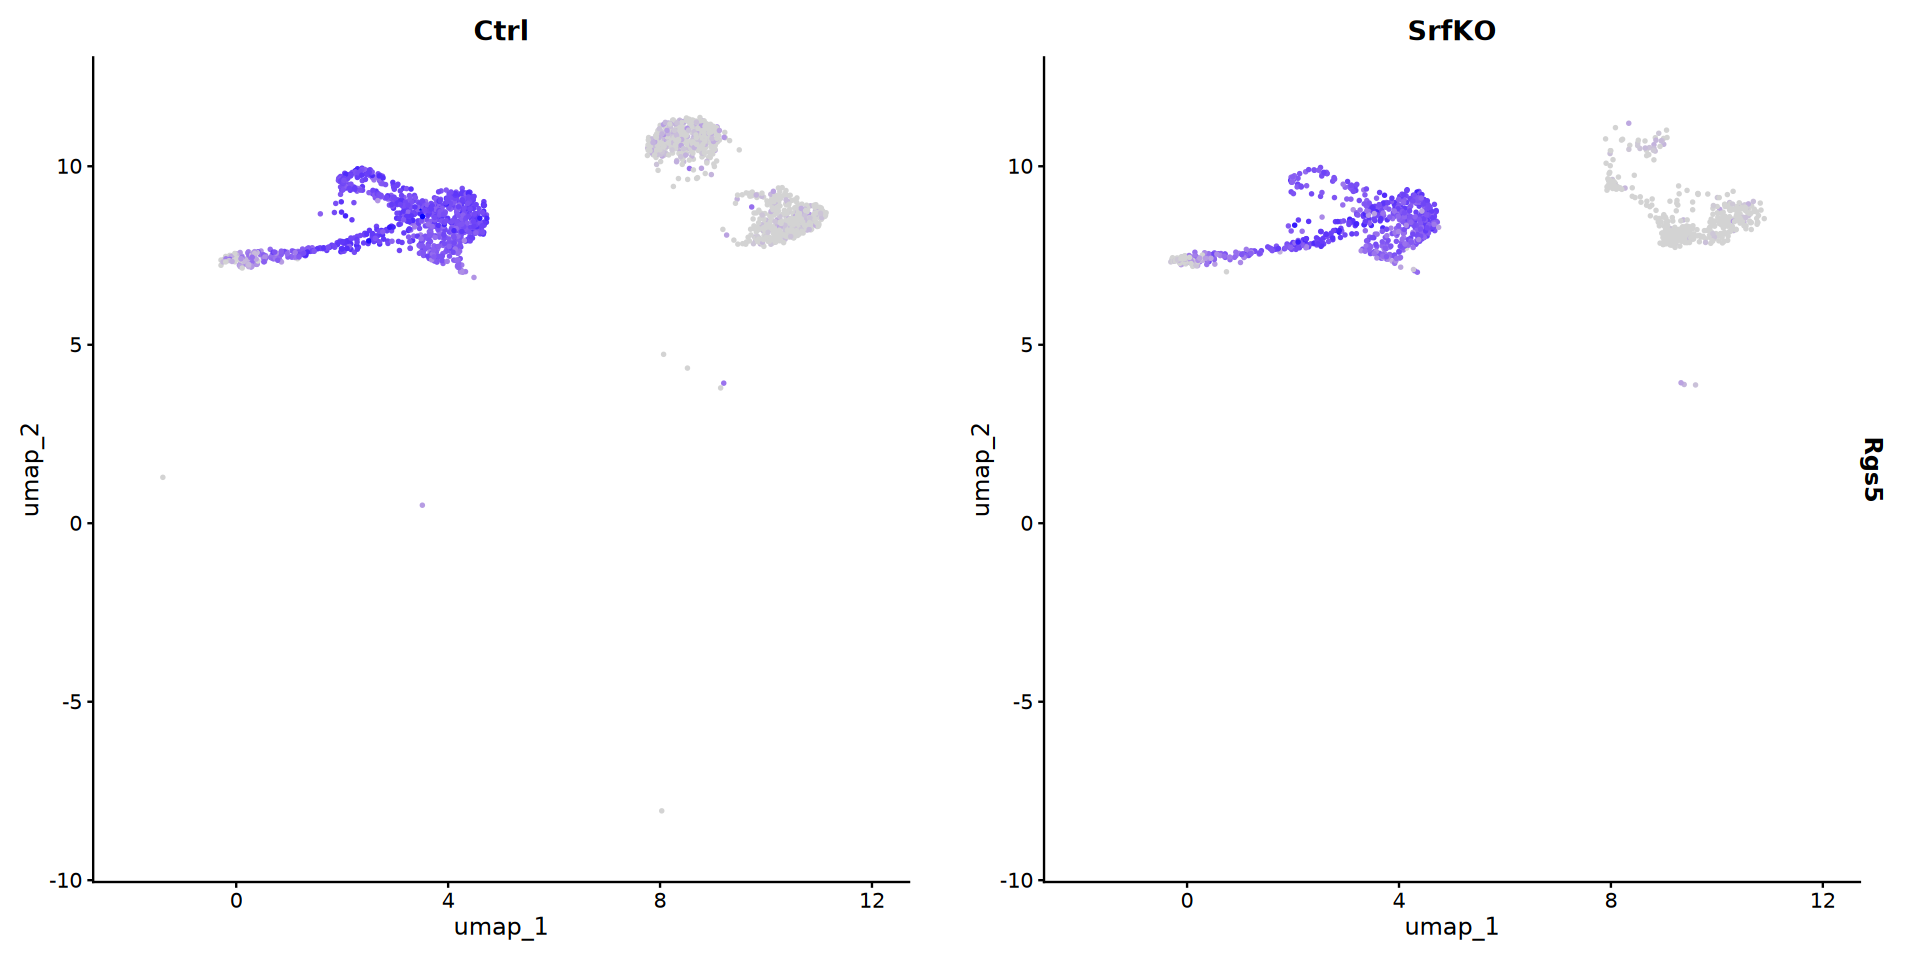

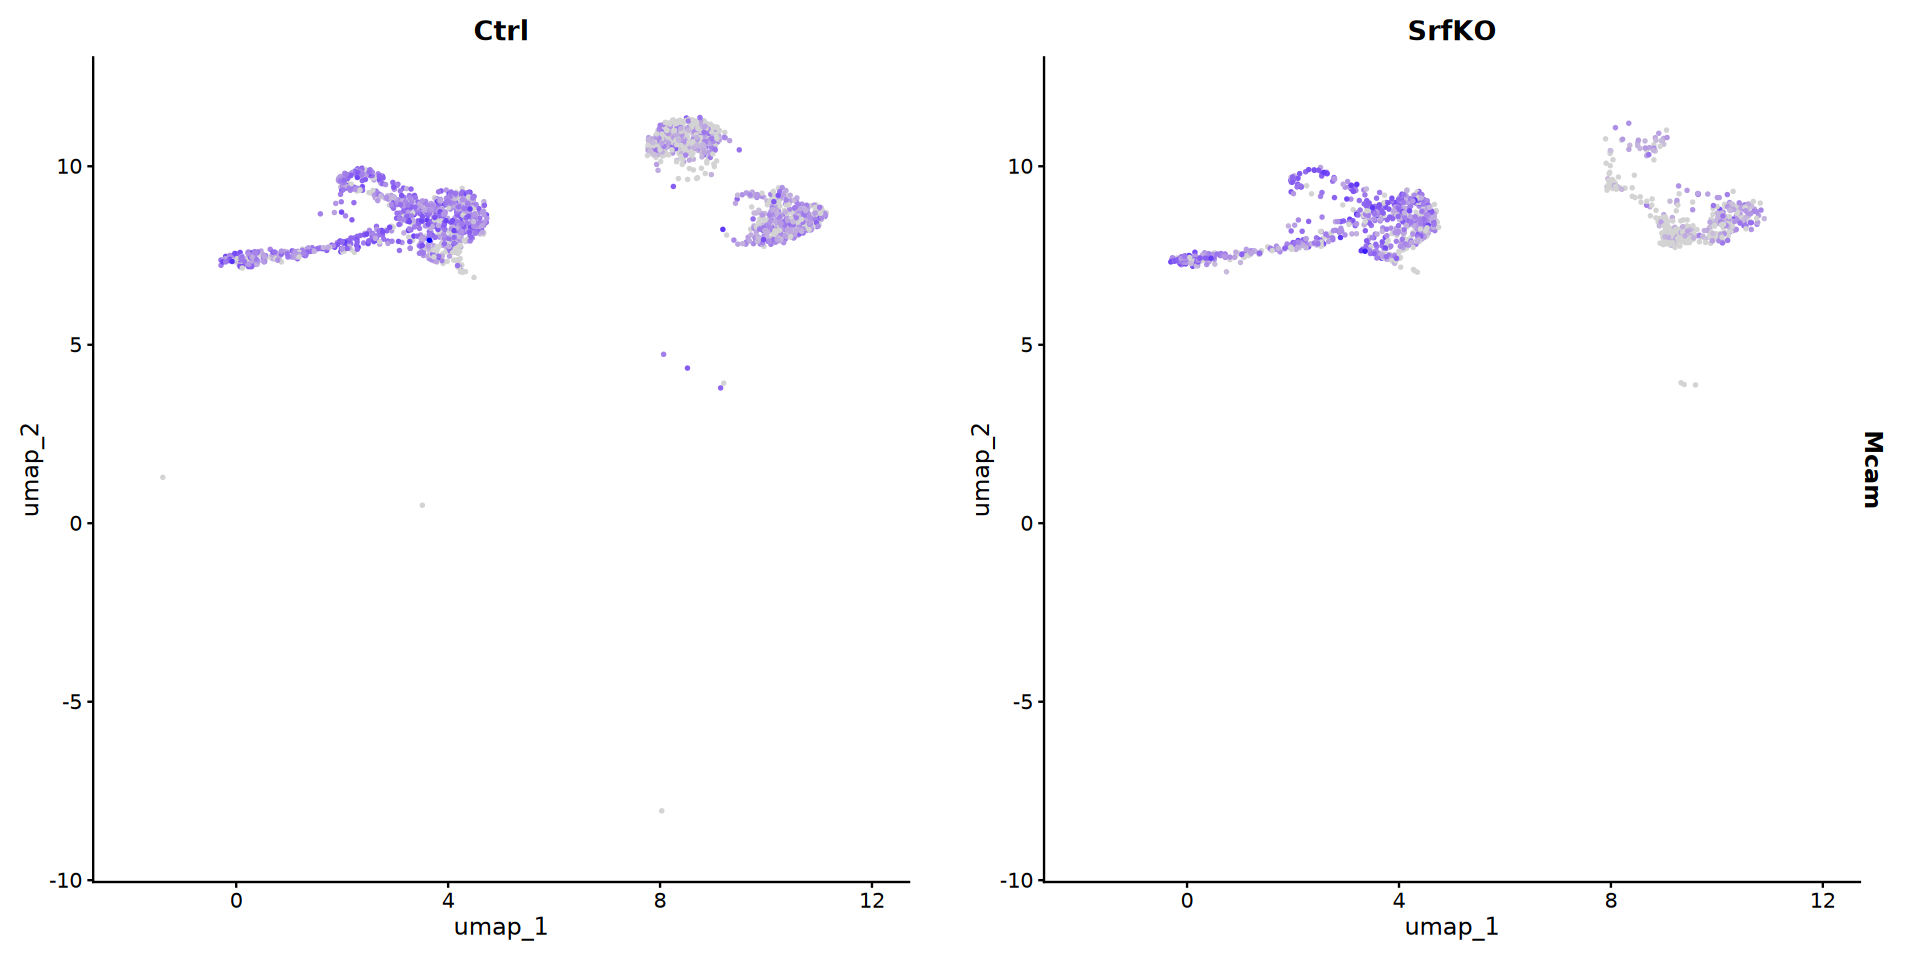

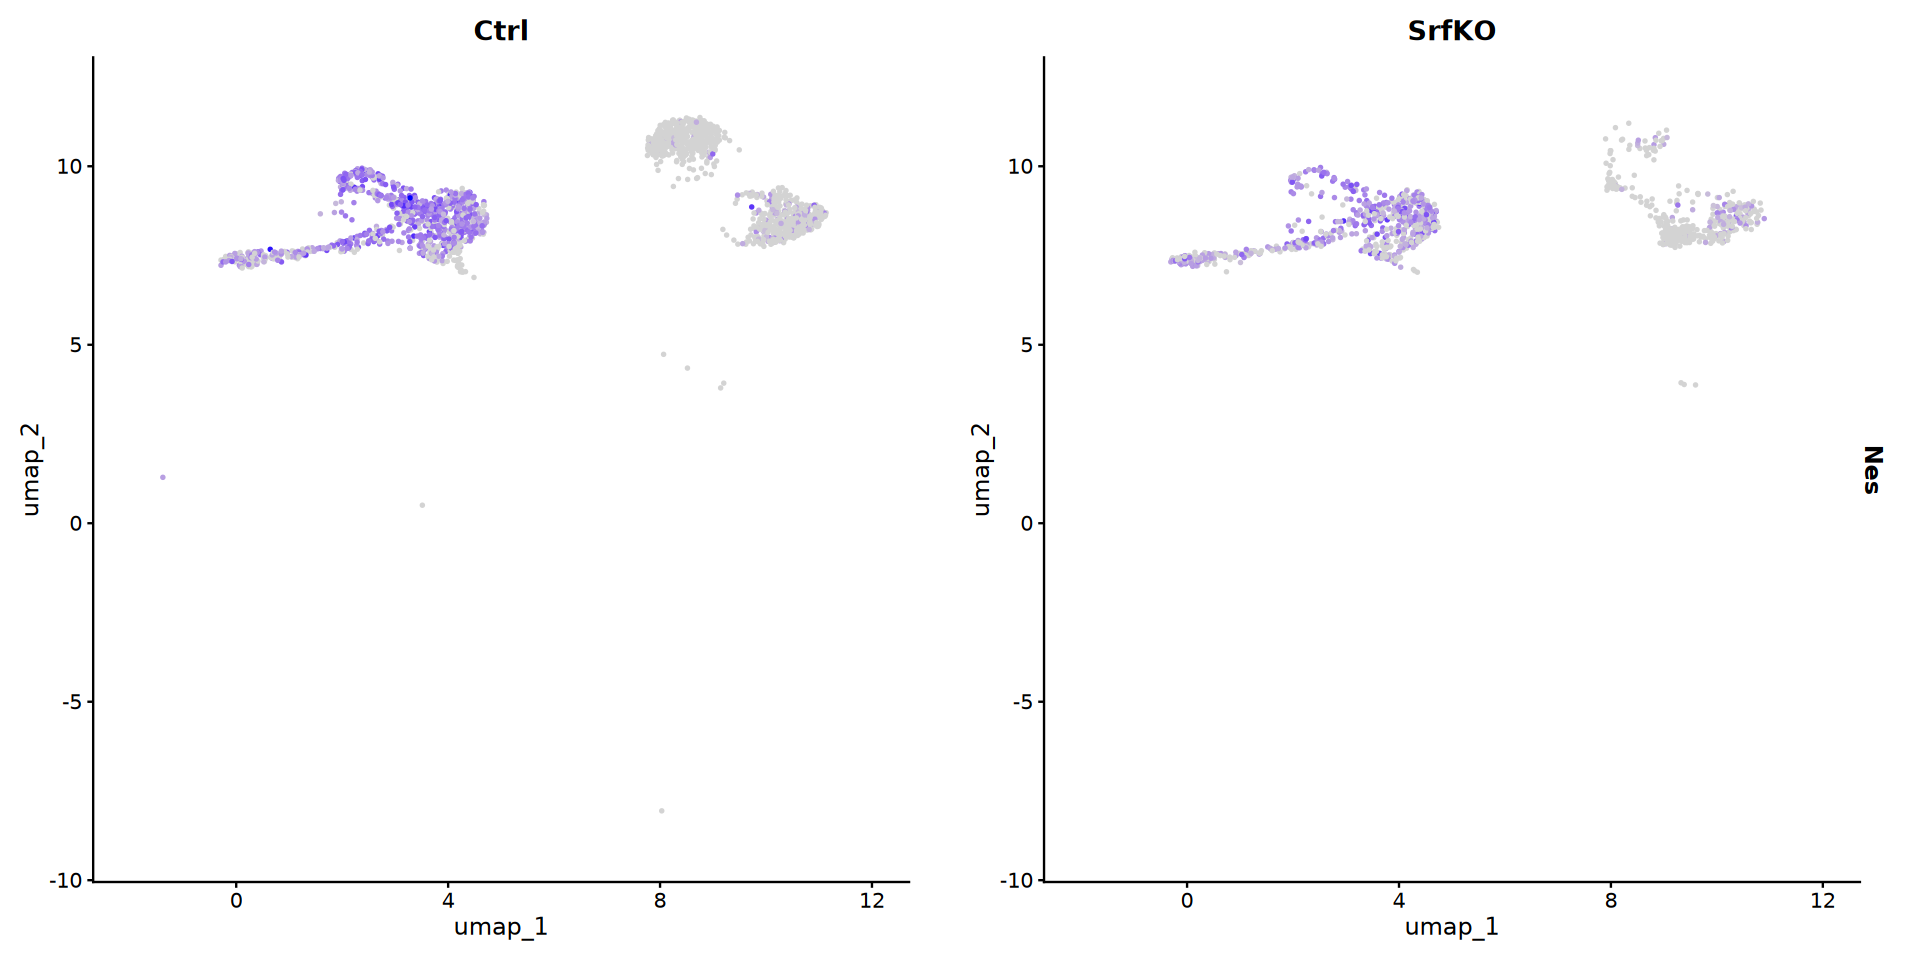

In [165]:
saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

FeaturePlot(Adult_Srfflox_SrfKO_SM_PV, features = c('Cnn1'), 
            pt.size=0.5,
            label=FALSE,
            repel = TRUE,
            split.by="genotype")

FeaturePlot(Adult_Srfflox_SrfKO_SM_PV, features = c('Actg2'), 
            pt.size=0.5,
            label=FALSE,
            repel = TRUE,
            split.by="genotype")

FeaturePlot(Adult_Srfflox_SrfKO_SM_PV, features = c('Pdgfrb'), 
            pt.size=0.5,
            label=FALSE,
            repel = TRUE,
            split.by="genotype")

FeaturePlot(Adult_Srfflox_SrfKO_SM_PV, features = c('Rgs5'), 
            pt.size=0.5,
            label=FALSE,
            repel = TRUE,
            split.by="genotype")

FeaturePlot(Adult_Srfflox_SrfKO_SM_PV, features = c('Mcam'), 
            pt.size=0.5,
            label=FALSE,
            repel = TRUE,
            split.by="genotype")

FeaturePlot(Adult_Srfflox_SrfKO_SM_PV, features = c('Nes'), 
            pt.size=0.5,
            label=FALSE,
            repel = TRUE,
            split.by="genotype")

options(saved) # restore old settings

In [124]:
Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_SM_PV, 
                                    features = "Acta2",
                                    group_by = "CellTypeBroad",
                                    split_by = "genotype",
                                   )
percent_stats

,SmoothMuscle_Ctrl,SmoothMuscle_SrfKO,Perivascular_Ctrl,Perivascular_SrfKO
,<dbl>,<dbl>,<dbl>,<dbl>
Acta2,100,51.02459,90.80919,31.70068


In [125]:
Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_SM_PV, 
                                    features = "Tagln",
                                    group_by = "CellTypeBroad",
                                    split_by = "genotype",
                                   )
percent_stats

,SmoothMuscle_Ctrl,SmoothMuscle_SrfKO,Perivascular_Ctrl,Perivascular_SrfKO
,<dbl>,<dbl>,<dbl>,<dbl>
Tagln,99.547,54.71311,82.01798,28.57143


In [126]:
Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_SM_PV, 
                                    features = "Myh11",
                                    group_by = "CellTypeBroad",
                                    split_by = "genotype",
                                   )
percent_stats

,SmoothMuscle_Ctrl,SmoothMuscle_SrfKO,Perivascular_Ctrl,Perivascular_SrfKO
,<dbl>,<dbl>,<dbl>,<dbl>
Myh11,100,78.07377,88.61139,67.21088


In [149]:
SMC_marker_pos <- WhichCells(object = Adult_Srfflox_SrfKO_SM_PV, expression = Acta2 > 0 & Tagln > 0 & Myh11 > 0)
SMC_marker_pos

[1] "Ctrl1___AAACCCACATCTAACG-1"  "Ctrl1___AAACGAAGTGACTGAG-1" 
   [3] "Ctrl1___AAACGCTAGACGGATC-1"  "Ctrl1___AAACGCTCACAGCTGC-1" 
   [5] "Ctrl1___AAACGCTTCGTTAGAC-1"  "Ctrl1___AAAGGATCAAACAGGC-1" 
   [7] "Ctrl1___AAAGGATCAGCACAGA-1"  "Ctrl1___AAAGGATTCGTAACCA-1" 
   [9] "Ctrl1___AAAGTCCGTGGGATTG-1"  "Ctrl1___AAAGTCCTCTCAGAAC-1" 
  [11] "Ctrl1___AACAAAGAGTACGAGC-1"  "Ctrl1___AACAAAGCAGTTGGTT-1" 
  [13] "Ctrl1___AACAGGGCATACCAGT-1"  "Ctrl1___AACAGGGCATAGCACT-1" 
  [15] "Ctrl1___AACCAACAGGAACGCT-1"  "Ctrl1___AACCAACCAGAGATTA-1" 
  [17] "Ctrl1___AACCAACGTATTCTCT-1"  "Ctrl1___AACCAACTCTAGATCG-1" 
  [19] "Ctrl1___AACCACATCCGCAACG-1"  "Ctrl1___AACCATGGTCGATTTG-1" 
  [21] "Ctrl1___AACCATGGTTTATGCG-1"  "Ctrl1___AACCTTTCACTGGACC-1" 
  [23] "Ctrl1___AACCTTTCAGACATCT-1"  "Ctrl1___AACCTTTGTAGGATAT-1" 
  [25] "Ctrl1___AACGGGATCGCTCCTA-1"  "Ctrl1___AACTTCTTCTAAACGC-1" 
  [27] "Ctrl1___AAGACAATCCCTCTCC-1"  "Ctrl1___AAGACAATCCGTGCGA-1" 
  [29] "Ctrl1___AAGACTCCAACGCATT-1"  "Ctrl1___AAGACTCGTCGTATTG-1" 
  [31] "Ctrl1___AAGACTCTCTTCCCAG-1"  "Ctrl1___AAGCATCCATGGCACC-1" 
  [33] "Ctrl1___AAGCGAGTCTCAATCT-1"  "Ctrl1___AAGGAATCACAAAGTA-1" 
  [35] "Ctrl1___AAGGTAAAGCAGCGAT-1"  "Ctrl1___AAGGTAAGTCGGTAAG-1" 
  [37] "Ctrl1___AAGTACCAGTAGCTCT-1"  "Ctrl1___AAGTACCAGTTATGGA-1" 
  [39] "Ctrl1___AAGTACCCATATGAAG-1"  "Ctrl1___AAGTCGTGTCGGTAAG-1" 
  [41] "Ctrl1___AAGTCGTGTCTCGCGA-1"  "Ctrl1___AATCACGCAATTGCAC-1" 
  [43] "Ctrl1___AATCACGGTATATGGA-1"  "Ctrl1___AATCGACAGTGTCATC-1" 
  [45] "Ctrl1___AATCGTGAGCACTCTA-1"  "Ctrl1___AATCGTGGTGCATACT-1" 
  [47] "Ctrl1___AATCGTGTCGTTCAGA-1"  "Ctrl1___AATGAAGAGGCAGCTA-1" 
  [49] "Ctrl1___AATGAAGTCACCGACG-1"  "Ctrl1___AATGACCCAACTGCCG-1" 
  [51] "Ctrl1___AATGACCTCAGAGTTC-1"  "Ctrl1___AATGCCAAGAAACCAT-1" 
  [53] "Ctrl1___AATGCCAGTGCGTCGT-1"  "Ctrl1___AATGGAAGTGTATTGC-1" 
  [55] "Ctrl1___AATTCCTCAAGCTGTT-1"  "Ctrl1___AATTTCCGTTGTGGAG-1" 
  [57] "Ctrl1___ACAAAGACAACTTGGT-1"  "Ctrl1___ACAAAGATCATAAGGA-1" 
  [59] "Ctrl1___ACAACCAAGAATTCAG-1"  "Ctrl1___ACAACCACATGGGATG-1" 
  [61] "Ctrl1___ACAAGCTAGTATAACG-1"  "Ctrl1___ACAAGCTTCGTTCTGC-1" 
  [63] "Ctrl1___ACACAGTAGATTAGCA-1"  "Ctrl1___ACACAGTCAGAGCCCT-1" 
  [65] "Ctrl1___ACACCAACAGAATGTA-1"  "Ctrl1___ACACGCGCATGAAGCG-1" 
  [67] "Ctrl1___ACACGCGGTATGAAAC-1"  "Ctrl1___ACACTGAGTAACATGA-1" 
  [69] "Ctrl1___ACAGAAAAGACCAGCA-1"  "Ctrl1___ACAGAAAAGCTGTGCC-1" 
  [71] "Ctrl1___ACAGCCGGTGTTCATG-1"  "Ctrl1___ACAGGGATCGCTAGCG-1" 
  [73] "Ctrl1___ACATCCCTCGGCTTCT-1"  "Ctrl1___ACATGCACAGGAACCA-1" 
  [75] "Ctrl1___ACATTTCCAATACCTG-1"  "Ctrl1___ACATTTCTCCAAGGGA-1" 
  [77] "Ctrl1___ACATTTCTCCCGAGAC-1"  "Ctrl1___ACCAACAGTTACACAC-1" 
  [79] "Ctrl1___ACCATTTCAGAGAAAG-1"  "Ctrl1___ACCCAAAAGGTTAAAC-1" 
  [81] "Ctrl1___ACCCTCACACCCTAGG-1"  "Ctrl1___ACCCTCAGTCTCGGGT-1" 
  [83] "Ctrl1___ACCCTCAGTGCCGTAC-1"  "Ctrl1___ACCCTTGCATTAGGAA-1" 
  [85] "Ctrl1___ACCGTTCAGGGTAGCT-1"  "Ctrl1___ACCTACCCAATGTTGC-1" 
  [87] "Ctrl1___ACCTACCCACTCTAGA-1"  "Ctrl1___ACCTACCGTCATCAGT-1" 
  [89] "Ctrl1___ACCTACCTCGCACGGT-1"  "Ctrl1___ACCTGTCCACACTTAG-1" 
  [91] "Ctrl1___ACCTGTCTCGAGCTGC-1"  "Ctrl1___ACGATGTGTACCCGCA-1" 
  [93] "Ctrl1___ACGATGTGTACCGTGC-1"  "Ctrl1___ACGGTCGCATACCAGT-1" 
  [95] "Ctrl1___ACGGTCGGTCAGGCAA-1"  "Ctrl1___ACGGTTAAGGTAAGTT-1" 
  [97] "Ctrl1___ACGGTTAGTATCTTCT-1"  "Ctrl1___ACGTAACAGGTAAGAG-1" 
  [99] "Ctrl1___ACGTAACCACTAAACC-1"  "Ctrl1___ACGTAACTCGAAGCAG-1" 
 [101] "Ctrl1___ACGTTCCAGAGCCCAA-1"  "Ctrl1___ACTACGAAGCGGGTTA-1" 
 [103] "Ctrl1___ACTATCTCATATGAAG-1"  "Ctrl1___ACTATCTTCGGATTAC-1" 
 [105] "Ctrl1___ACTATGGAGAGGTCGT-1"  "Ctrl1___ACTCTCGTCGTTAGAC-1" 
 [107] "Ctrl1___ACTGATGTCTTCTCAA-1"  "Ctrl1___ACTGTGACACATGACT-1" 
 [109] "Ctrl1___ACTGTGAGTGGACCAA-1"  "Ctrl1___ACTGTGAGTTCCCAAA-1" 
 [111] "Ctrl1___ACTGTGAGTTCTGAGT-1"  "Ctrl1___ACTGTGATCTGTTGGA-1" 
 [113] "Ctrl1___ACTTAGGCAAATGGAT-1"  "Ctrl1___ACTTAGGCATGCCGAC-1" 
 [115] "Ctrl1___ACTTATCCAATGCTCA-1"  "Ctrl1___ACTTCCGGTGGCTAGA-1" 
 [117] "Ctrl1___ACTTCCGTCGATTGAC-1"  "Ctrl1___ACTTTCACAGGTGTTT-1" 
 [119] "Ctrl1___AGAAATGAGAGCTGCA-1"  "Ctrl1___AGAA

In [152]:
Adult_Srfflox_SrfKO_SM_PV_SMC_marker_pos <- subset(Adult_Srfflox_SrfKO_SM_PV, cells = SMC_marker_pos);
Adult_Srfflox_SrfKO_SM_PV_SMC_marker_pos

An object of class Seurat 
26486 features across 2034 samples within 1 assay 
Active assay: RNA (26486 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.rpca, umap

In [154]:
table(Adult_Srfflox_SrfKO_SM_PV_SMC_marker_pos$CellTypeBroad,Adult_Srfflox_SrfKO_SM_PV_SMC_marker_pos$genotype);

              
               Ctrl SrfKO
  Perivascular  764   180
  SmoothMuscle  879   211

In [155]:
Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_SM_PV, 
                                    features = "Cnn1",
                                    group_by = "CellTypeBroad",
                                    split_by = "genotype",
                                   )
percent_stats

,SmoothMuscle_Ctrl,SmoothMuscle_SrfKO,Perivascular_Ctrl,Perivascular_SrfKO
,<dbl>,<dbl>,<dbl>,<dbl>
Cnn1,99.20725,38.72951,12.68731,13.46939


In [156]:
Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_SM_PV, 
                                    features = "Actg2",
                                    group_by = "CellTypeBroad",
                                    split_by = "genotype",
                                   )
percent_stats

,SmoothMuscle_Ctrl,SmoothMuscle_SrfKO,Perivascular_Ctrl,Perivascular_SrfKO
,<dbl>,<dbl>,<dbl>,<dbl>
Actg2,98.98075,42.21311,11.18881,4.62585


In [157]:
Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_SM_PV, 
                                    features = "Pdgfrb",
                                    group_by = "CellTypeBroad",
                                    split_by = "genotype",
                                   )
percent_stats

,SmoothMuscle_Ctrl,SmoothMuscle_SrfKO,Perivascular_Ctrl,Perivascular_SrfKO
,<dbl>,<dbl>,<dbl>,<dbl>
Pdgfrb,5.662514,12.5,96.1039,98.09524


In [158]:
Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_SM_PV, 
                                    features = "Mcam",
                                    group_by = "CellTypeBroad",
                                    split_by = "genotype",
                                   )
percent_stats

,SmoothMuscle_Ctrl,SmoothMuscle_SrfKO,Perivascular_Ctrl,Perivascular_SrfKO
,<dbl>,<dbl>,<dbl>,<dbl>
Mcam,58.66365,37.90984,84.61538,82.17687


In [159]:
Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_SM_PV, 
                                    features = "Nes",
                                    group_by = "CellTypeBroad",
                                    split_by = "genotype",
                                   )
percent_stats

,SmoothMuscle_Ctrl,SmoothMuscle_SrfKO,Perivascular_Ctrl,Perivascular_SrfKO
,<dbl>,<dbl>,<dbl>,<dbl>
Nes,10.64553,13.93443,69.63037,62.9932


In [160]:
Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
percent_stats <- Percent_Expressing(seurat_object = Adult_Srfflox_SrfKO_SM_PV, 
                                    features = "Rgs5",
                                    group_by = "CellTypeBroad",
                                    split_by = "genotype",
                                   )
percent_stats

,SmoothMuscle_Ctrl,SmoothMuscle_SrfKO,Perivascular_Ctrl,Perivascular_SrfKO
,<dbl>,<dbl>,<dbl>,<dbl>
Rgs5,25.25481,10.2459,96.8032,93.7415


Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


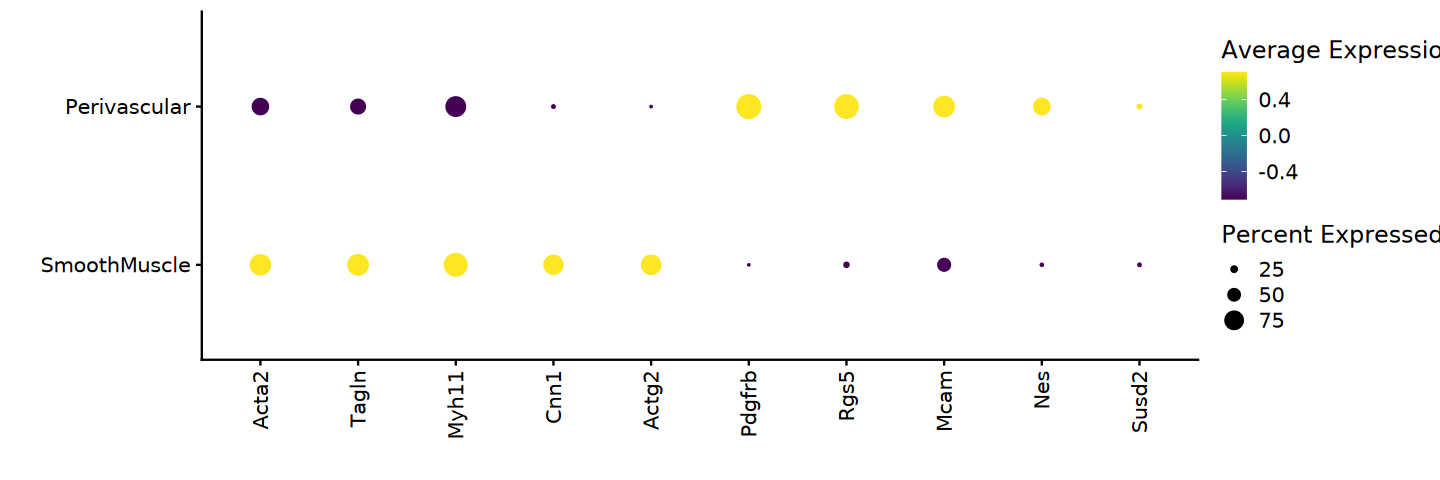

In [161]:
genes <- c("Acta2","Tagln","Myh11","Cnn1","Actg2","Pdgfrb", "Rgs5", "Mcam","Nes","Susd2");
DotPlot(Adult_Srfflox_SrfKO_SM_PV, features=genes) + RotatedAxis() + scale_color_viridis(option="D") + theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + ylab('') + xlab('');

Warning message:
“Scaling data with a low number of groups may produce misleading results”


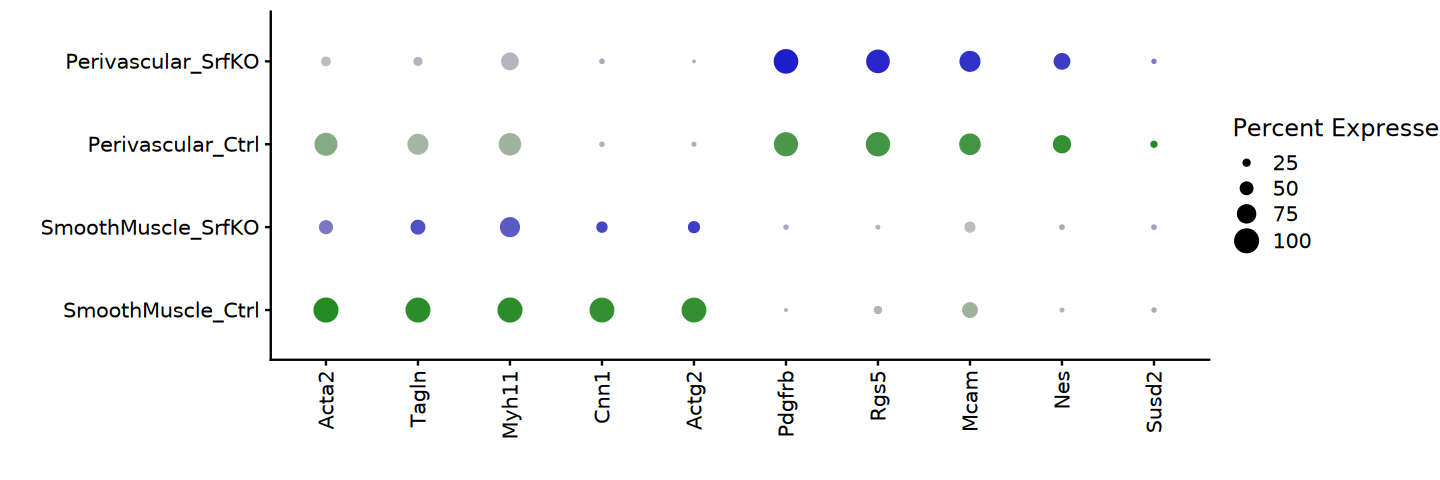

In [162]:
genes <- c("Acta2","Tagln","Myh11","Cnn1","Actg2","Pdgfrb", "Rgs5", "Mcam","Nes","Susd2");
DotPlot(Adult_Srfflox_SrfKO_SM_PV, split.by="genotype", cols=c("forestgreen","mediumblue"), features=genes) + RotatedAxis() + theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + ylab('') + xlab('');

In [67]:
# Tried to change order of plotting as below but it didn't work (https://www.r-bloggers.com/2007/10/reorder-factor-levels/)

# check
# levels(factor("CellTypeBroad"))
# levels(factor("genotype"))
#Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$CellTypeBroad
#levels(Adult_Srfflox_SrfKO_SM_PV)
#Idents(Adult_Srfflox_SrfKO_SM_PV) <- Adult_Srfflox_SrfKO_SM_PV$genotype
#levels(Adult_Srfflox_SrfKO_SM_PV)

#Dropped two of the rows from graph, not sure why
## To reorder the levels:
## note, if x is not a factor use levels(factor(x))
# "CellTypeBroad" = factor("CellTypeBroad",levels("CellTypeBroad")[c("SmoothMuscle","Perivascular",1:2)])
# "genotype" = factor("genotype",levels("genotype")[c("Ctrl","SrfKO",1:2)])

#levels(factor("CellTypeBroad", c("SmoothMuscle","Perivascular",1:2)))
#levels(factor("genotype", c("Ctrl","SrfKO",1:2)))

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


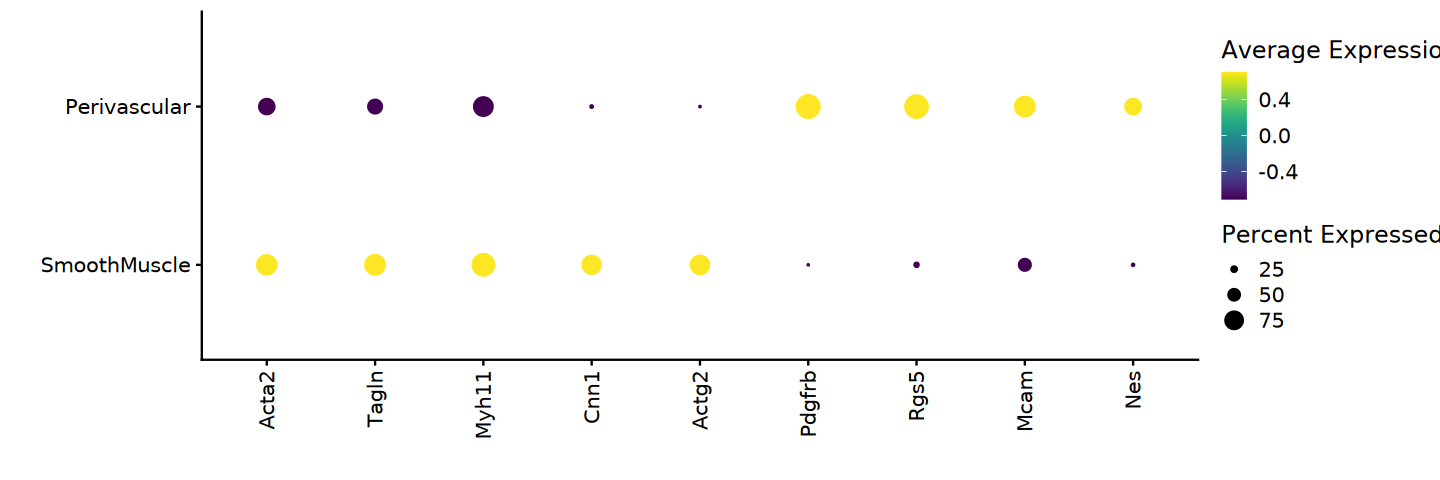

In [163]:
saved <- options(repr.plot.width = 12, repr.plot.height = 4) # Make the plots bigger from here on out, save old options

genes <- c("Acta2","Tagln","Myh11","Cnn1","Actg2","Pdgfrb", "Rgs5", "Mcam","Nes");
DotPlot(Adult_Srfflox_SrfKO_SM_PV, features=genes) + RotatedAxis() + scale_color_viridis(option="D") + theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + ylab('') + xlab('');

options(saved) # restore old settings

Warning message:
“Scaling data with a low number of groups may produce misleading results”


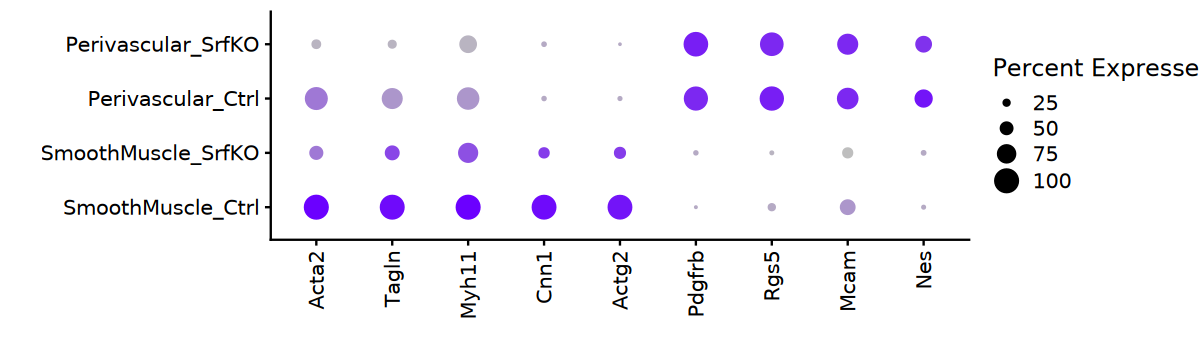

In [164]:
saved <- options(repr.plot.width = 10, repr.plot.height = 3) # Make the plots bigger from here on out, save old options

genes <- c("Acta2","Tagln","Myh11","Cnn1","Actg2","Pdgfrb", "Rgs5", "Mcam","Nes");
DotPlot(Adult_Srfflox_SrfKO_SM_PV, split.by="genotype", cols=c("#6b00ff","#6b00ff"), features=genes) + RotatedAxis() + theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + ylab('') + xlab('');

options(saved) # restore old settings

Warning message:
“Scaling data with a low number of groups may produce misleading results”


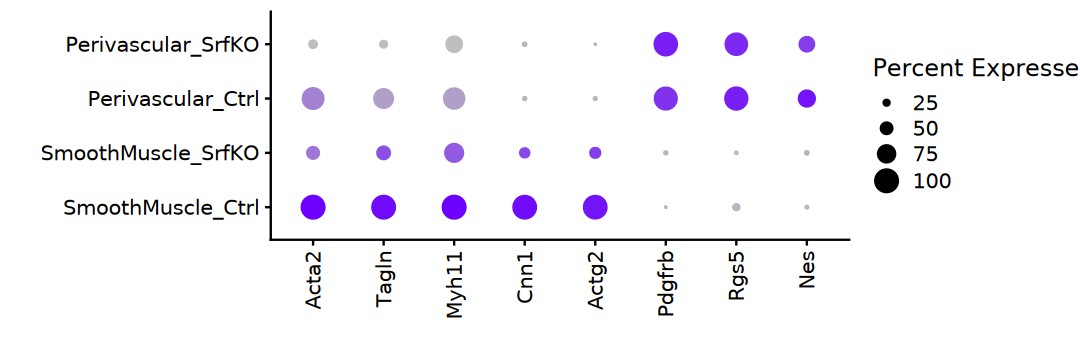

In [167]:
saved <- options(repr.plot.width = 9, repr.plot.height = 3) # Make the plots bigger from here on out, save old options

genes <- c("Acta2","Tagln","Myh11","Cnn1","Actg2","Pdgfrb", "Rgs5","Nes");
DotPlot(Adult_Srfflox_SrfKO_SM_PV, split.by="genotype", cols=c("#6b00ff","#6b00ff"), features=genes) + RotatedAxis() + theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + ylab('') + xlab('');

options(saved) # restore old settings